# [1교시]

## runpod에서 실습

### 기본환경 셋팅

- exaone35
    - data[폴더]
    - outputs[폴더]
    - scripts[폴더]
    - requirements-train.txt[파일]
    - exaone.ipynb[파일]

- cd /workspace/exaone35

- bash scripts/setup_runpod.sh

- source .venv/bin/activate

In [1]:
from pathlib import Path
# 설명: pathlib에서 Path 기능을 가져온다.
import os
# 설명: os 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
import sys
# 설명: sys 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.

PROJECT_DIR = Path('/workspace/exaone35')
# 설명: 실습 프로젝트 폴더 경로를 저장한다.
if not PROJECT_DIR.exists():
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    PROJECT_DIR = Path.cwd()
    # 설명: 실습 프로젝트 폴더 경로를 저장한다.

os.chdir(PROJECT_DIR)
# 설명: 현재 작업 폴더를 프로젝트 폴더로 이동한다.

MODEL_ID = 'LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct'
# 설명: 사용할 Hugging Face 모델 이름을 저장한다.
SYSTEM_PROMPT = 'You are EXAONE model from LG AI Research, a helpful assistant.'
# 설명: 모델에게 기본 역할을 알려주는 시스템 프롬프트를 저장한다.

os.environ['HF_HOME'] = '/workspace/.cache/huggingface'
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
os.environ['MODEL_ID'] = MODEL_ID
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
os.environ['DISABLE_DOTENV'] = '1'
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
os.environ.pop('HF_TOKEN', None)
# 설명: 환경변수에서 지정한 값을 제거한다.

print('project_dir:', PROJECT_DIR)
# 설명: 확인용 결과를 화면에 출력한다.
print('python:', sys.executable)
# 설명: 확인용 결과를 화면에 출력한다.
print('hf_home:', os.environ['HF_HOME'])
# 설명: 확인용 결과를 화면에 출력한다.
print('model_id:', MODEL_ID)
# 설명: 확인용 결과를 화면에 출력한다.
print('disable_dotenv:', os.environ['DISABLE_DOTENV'])# 설명: 확인용 결과를 화면에 출력한다.


project_dir: /workspace
python: /usr/bin/python
hf_home: /workspace/.cache/huggingface
model_id: LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct
disable_dotenv: 1


### GPU 설정 확인

In [2]:
!nvidia-smi
# 설명: NVIDIA GPU 상태, 사용량, 드라이버 정보를 확인하는 명령이다
!python3 --version || true# 설명: 리눅스 환경의 Python3 버전을 확인하는 명령이다


Tue May 26 11:50:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        On  |   00000000:41:00.0 Off |                  Off |
|  0%   31C    P8             24W /  450W |       1MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### BF16 LoFA 기본으로 사용
- gpu 사용 가능 여부 확인

In [3]:
import importlib.metadata as metadata
# 설명: importlib.metadata 모듈을 metadata라는 짧은 이름으로 불러온다.
import torch
# 설명: torch 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.

packages = ['torch', 'transformers', 'accelerate', 'datasets', 'peft', 'trl', 'bitsandbytes', 'huggingface_hub']
# 설명: 설치 여부와 버전을 확인할 패키지 이름 목록이다
for name in packages:
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    try:
        # 설명: 오류가 날 수 있는 코드를 안전하게 시도하는 블록을 시작한다.
        print(f'{name}:', metadata.version(name))
        # 설명: 설치된 패키지의 버전을 확인한다
    except metadata.PackageNotFoundError:
        # 설명: 패키지가 설치되어 있지 않을 때 발생하는 예외를 처리한다
        print(f'{name}: NOT_INSTALLED')
        # 설명: 확인용 결과를 화면에 출력한다.

print('cuda available:', torch.cuda.is_available())
# 설명: CUDA GPU를 사용할 수 있는지 확인한다.
if torch.cuda.is_available():
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    print('gpu:', torch.cuda.get_device_name(0))
    # 설명: 확인용 결과를 화면에 출력한다.
    print('torch cuda:', torch.version.cuda)
    # 설명: 확인용 결과를 화면에 출력한다.
    print('bf16 supported:', torch.cuda.is_bf16_supported())
    # 설명: bfloat16은 GPU 메모리를 줄이면서 빠르게 계산하기 위한 자료형이다
    free, total = torch.cuda.mem_get_info(0)
    # 설명: GPU 메모리 여유량과 전체량을 확인한다.
    print('gpu memory free GB:', round(free / 1024**3, 2))
    # 설명: 확인용 결과를 화면에 출력한다.
    print('gpu memory total GB:', round(total / 1024**3, 2))    # 설명: 확인용 결과를 화면에 출력한다.


torch: 2.4.1+cu124
transformers: 5.1.0
accelerate: 1.13.0
datasets: 4.8.5
peft: 0.19.1
trl: 1.5.0
bitsandbytes: 0.49.2
huggingface_hub: 1.16.1
cuda available: True
gpu: NVIDIA GeForce RTX 4090
torch cuda: 12.4
bf16 supported: True
gpu memory free GB: 23.13
gpu memory total GB: 23.52


### 허깅페이스 로그인
- 대부분 고성능 모델은  허깅페이스에서 사용신청을 하고 권한을 얻은다음 로그인을해야 사용가능

In [4]:
from huggingface_hub import notebook_login
# 설명: huggingface_hub에서 notebook_login 기능을 가져온다.

os.environ.pop('HF_TOKEN', None)
# 설명: 환경변수에서 지정한 값을 제거한다.
notebook_login(skip_if_logged_in=False)# 설명: 노트북 환경에서 Hugging Face 로그인을 진행한다.


### 우리가 전달한 토큰값으로 로그인이 되었다면 아래 셀의 출력을통해 확인

In [ ]:
from huggingface_hub import get_token, whoami
# 설명: huggingface_hub에서 get_token, whoami 기능을 가져온다.

HF_TOKEN = get_token()
# 설명: 저장된 Hugging Face 토큰을 가져온다.
if not HF_TOKEN:
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    raise RuntimeError('Hugging Face 토큰이 저장되지 않았습니다. 로그인 셀을 다시 실행하세요.')
    # 설명: 조건이 맞지 않을 때 의도적으로 오류를 발생시켜 실행을 중단한다.

info = whoami(token=HF_TOKEN)
# 설명: 토큰으로 로그인된 계정 정보를 확인한다.
print('logged in user:', info.get('name'))
# 설명: 확인용 결과를 화면에 출력한다.
print('token prefix:', HF_TOKEN[:6] + '***')# 설명: 확인용 결과를 화면에 출력한다.


### 셈플데이터 구조 확인
- system : 모델역활 설명
- user : 질문
- assistant : 모델이 학습해야할 정답 답변

In [6]:
import json
# 설명: json 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
from pathlib import Path
# 설명: pathlib에서 Path 기능을 가져온다.

TRAIN_FILE = Path('data/train.jsonl')
# 설명: 학습 데이터 JSONL 파일 경로를 저장한다.
VALID_FILE = Path('data/valid.jsonl')
# 설명: 검증 데이터 JSONL 파일 경로를 저장한다.
VALID_ROLES = {'system', 'user', 'assistant'}
# 설명: 허용할 대화 역할 이름을 집합으로 저장한다.

def validate_jsonl(path: Path) -> int:
    # 설명: validate_jsonl 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
    count = 0
    # 설명: count 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    with path.open(encoding='utf-8') as f:
        # 설명: 파일, 세션, 메모리 같은 자원을 안전하게 열고 닫기 위한 블록이다.
        for line_no, line in enumerate(f, start=1):
            # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
            line = line.strip()
            # 설명: 문자열 앞뒤의 불필요한 공백을 제거한다.
            if not line:
                # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
                continue
                # 설명: 이번 반복을 건너뛰고 다음 반복으로 넘어간다.
            count += 1
            # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
            row = json.loads(line)
            # 설명: JSON 문자열을 파이썬 딕셔너리/리스트로 변환한다.
            messages = row.get('messages')
            # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
            if not isinstance(messages, list) or not messages:
                # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
                raise ValueError(f'{path}:{line_no}: messages must be a non-empty list')
                # 설명: 조건이 맞지 않을 때 의도적으로 오류를 발생시켜 실행을 중단한다.
            if messages[-1].get('role') != 'assistant':
                # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
                raise ValueError(f'{path}:{line_no}: last message must be assistant')
                # 설명: 조건이 맞지 않을 때 의도적으로 오류를 발생시켜 실행을 중단한다.
            roles = [m.get('role') for m in messages]
            # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
            if 'user' not in roles or 'assistant' not in roles:
                # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
                raise ValueError(f'{path}:{line_no}: user and assistant messages are required')
                # 설명: 조건이 맞지 않을 때 의도적으로 오류를 발생시켜 실행을 중단한다.
            for idx, message in enumerate(messages):
                # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
                if message.get('role') not in VALID_ROLES:
                    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
                    raise ValueError(f'{path}:{line_no}: invalid role at message {idx}')
                    # 설명: 조건이 맞지 않을 때 의도적으로 오류를 발생시켜 실행을 중단한다.
                if not isinstance(message.get('content'), str) or not message['content'].strip():
                    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
                    raise ValueError(f'{path}:{line_no}: empty content at message {idx}')
                    # 설명: 조건이 맞지 않을 때 의도적으로 오류를 발생시켜 실행을 중단한다.
    return count
    # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.

print('train rows:', validate_jsonl(TRAIN_FILE))
# 설명: 확인용 결과를 화면에 출력한다.
print('valid rows:', validate_jsonl(VALID_FILE))
# 설명: 확인용 결과를 화면에 출력한다.
print('validation: OK')# 설명: 확인용 결과를 화면에 출력한다.


train rows: 30
valid rows: 5
validation: OK


### 데이터 예시 보기

In [7]:
with TRAIN_FILE.open(encoding='utf-8') as f:
    # 설명: 파일, 세션, 메모리 같은 자원을 안전하게 열고 닫기 위한 블록이다.
    first_sample = json.loads(next(f))
    # 설명: JSON 문자열을 파이썬 딕셔너리/리스트로 변환한다.

first_sample# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.


{'messages': [{'role': 'system',
   'content': 'You are EXAONE model from LG AI Research, a helpful assistant.'},
  {'role': 'user', 'content': '한국어 형태소 분석이 왜 중요한가요?'},
  {'role': 'assistant',
   'content': '한국어는 조사와 어미가 단어에 붙어 의미와 문법 기능을 만드는 교착어입니다. 형태소 분석을 하면 문장을 의미 단위로 나누고 품사와 어절 관계를 파악할 수 있어 검색, 챗봇, 번역, 감성 분석 같은 자연어 처리 작업의 정확도를 높일 수 있습니다.'}]}

### 데이터셋 로드(만들기)

In [8]:
from datasets import load_dataset
# 설명: datasets에서 load_dataset 기능을 가져온다.

raw_dataset = load_dataset('json', data_files={
# 설명: datasets 라이브러리로 데이터셋을 불러온다.
    'train': str(TRAIN_FILE),
    # 설명: 딕셔너리나 함수 인자에서 키와 값을 한 쌍으로 지정한다.
    'validation': str(VALID_FILE),
    # 설명: 딕셔너리나 함수 인자에서 키와 값을 한 쌍으로 지정한다.
})
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

raw_dataset# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 30
    })
    validation: Dataset({
        features: ['messages'],
        num_rows: 5
    })
})

### 모델 로드

In [9]:
from transformers import AutoTokenizer
# 설명: transformers에서 AutoTokenizer 기능을 가져온다.

DTYPE = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
# 설명: bfloat16은 GPU 메모리를 줄이면서 빠르게 계산하기 위한 자료형이다
print('selected dtype:', DTYPE)
# 설명: 확인용 결과를 화면에 출력한다.

tokenizer = AutoTokenizer.from_pretrained(
# 설명: 사전학습 모델에 맞는 토크나이저를 불러온다.
    MODEL_ID,
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    trust_remote_code=True,
    # 설명: trust_remote_code 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    token=HF_TOKEN,
    # 설명: token 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

if tokenizer.pad_token_id is None:
    # 설명: 패딩 토큰 ID를 확인하거나 설정해 배치 처리를 가능하게 한다
    tokenizer.pad_token = tokenizer.eos_token
    # 설명: tokenizer.pad_token 변수에 오른쪽 계산 결과나 설정값을 저장한다.

print('vocab size:', len(tokenizer))
# 설명: 확인용 결과를 화면에 출력한다.
print('pad token:', tokenizer.pad_token, tokenizer.pad_token_id)
# 설명: 패딩 토큰 ID를 확인하거나 설정해 배치 처리를 가능하게 한다
print('eos token:', tokenizer.eos_token, tokenizer.eos_token_id)# 설명: 문장 생성 종료를 판단할 EOS 토큰 ID를 사용한다


selected dtype: torch.bfloat16


config.json:   0%|          | 0.00/1.04k [00:00<?, ?B/s]

configuration_exaone.py:   0%|          | 0.00/11.3k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct:
- configuration_exaone.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/70.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.96M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/563 [00:00<?, ?B/s]

vocab size: 102400
pad token: [PAD] 0
eos token: [|endofturn|] 361


In [10]:
from transformers import AutoModelForCausalLM
# 설명: transformers에서 AutoModelForCausalLM 기능을 가져온다.

model = AutoModelForCausalLM.from_pretrained(
# 설명: 다음 토큰 예측용 사전학습 언어모델을 불러온다.
    MODEL_ID,
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    torch_dtype=DTYPE,
    # 설명: torch_dtype 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    device_map='auto',
    # 설명: device_map 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    trust_remote_code=True,
    # 설명: trust_remote_code 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    low_cpu_mem_usage=True,
    # 설명: low_cpu_mem_usage 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    token=HF_TOKEN,
    # 설명: token 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
model.eval()
# 설명: 모델을 추론 모드로 바꾼다.

first_device = next(model.parameters()).device
# 설명: 모델 파라미터가 올라간 첫 번째 장치 정보를 저장한다
print('loaded:', True)
# 설명: 확인용 결과를 화면에 출력한다.
print('first parameter device:', first_device)
# 설명: 확인용 결과를 화면에 출력한다.
if torch.cuda.is_available():
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    print('memory allocated GB:', round(torch.cuda.memory_allocated() / 1024**3, 3))
    # 설명: 확인용 결과를 화면에 출력한다.
    print('memory reserved GB:', round(torch.cuda.memory_reserved() / 1024**3, 3))    # 설명: 확인용 결과를 화면에 출력한다.


`torch_dtype` is deprecated! Use `dtype` instead!


modeling_exaone.py:   0%|          | 0.00/24.0k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct:
- modeling_exaone.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors.index.json:   0%|          | 0.00/22.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

loaded: True
first parameter device: cuda:0
memory allocated GB: 4.48
memory reserved GB: 4.969


### 원본 모델 추론

In [11]:
prompt = '한국어 형태소 분석이 왜 중요한지 짧게 설명해줘.'
# 설명: prompt 변수에 오른쪽 계산 결과나 설정값을 저장한다.
messages = [
# 설명: 모델에게 전달할 system/user/assistant 대화 메시지 목록이다
    {'role': 'system', 'content': SYSTEM_PROMPT},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {'role': 'user', 'content': prompt},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
]
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

# 최신 Transformers에서는 apply_chat_template가 BatchEncoding을 반환할 수 있습니다.
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 그래서 Tensor 하나를 generate에 넘기지 않고, input_ids/attention_mask를 dict로 풀어 전달합니다.
# 설명: 패딩이 아닌 실제 토큰 위치를 모델에 알려주는 마스크다
encoded = tokenizer.apply_chat_template(
# 설명: 대화 메시지를 모델 입력 형식의 프롬프트로 변환한다.
    messages,
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    tokenize=True,
    # 설명: tokenize 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    add_generation_prompt=True,
    # 설명: add_generation_prompt 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    return_tensors='pt',
    # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.
    return_dict=True,
    # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.
).to(first_device)
# 설명: 텐서나 모델 입력을 지정한 장치로 이동한다.

inputs = dict(encoded)
# 설명: generate 함수에 넣기 위해 인코딩 결과를 딕셔너리로 바꾼 값이다
prompt_length = inputs['input_ids'].shape[-1]
# 설명: 프롬프트 토큰 길이로, 나중에 새로 생성된 답변만 자를 때 사용한다

with torch.no_grad():
    # 설명: 파일, 세션, 메모리 같은 자원을 안전하게 열고 닫기 위한 블록이다.
    output_ids = model.generate(
    # 설명: 모델이 입력을 바탕으로 새 토큰을 생성한다.
        **inputs,
        # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
        max_new_tokens=256,
        # 설명: max_new_tokens 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        do_sample=False,
        # 설명: do_sample 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        pad_token_id=tokenizer.pad_token_id,
        # 설명: 패딩 토큰 ID를 확인하거나 설정해 배치 처리를 가능하게 한다
        eos_token_id=tokenizer.eos_token_id,
        # 설명: 문장 생성 종료를 판단할 EOS 토큰 ID를 사용한다
    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

new_tokens = output_ids[0][prompt_length:]
# 설명: 프롬프트를 제외하고 모델이 새로 생성한 토큰만 잘라낸 값이다
response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
# 설명: 토큰 ID를 사람이 읽을 수 있는 문자열로 바꾼다.
print(response)# 설명: 확인용 결과를 화면에 출력한다.


한국어 형태소 분석은 문장의 의미를 정확하게 이해하는 데 핵심적입니다. 형태소 분석을 통해 단어를 그 기본 의미 단위인 형태소로 분해함으로써:

1. **의미 구분**: 복합어와 혼용어를 명확히 구분하여 단어의 본래 의미를 정확히 파악할 수 있습니다.
2. **문맥 이해**: 단어의 역할(명사, 동사 등)을 파악해 문맥에 따른 정확한 해석이 가능해집니다.
3. **자연어 처리**: 기계 학습 모델이 한국어의 복잡한 구조를 효과적으로 학습하고 처리할 수 있도록 지원합니다.

이러한 분석은 번역, 정보 검색, 챗봇 대화 등 다양한 자연어 처리 작업의 정확성을 크게 향상시킵니다.


학습전 gpu메모리 정리

In [12]:
import gc
# 설명: gc 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
del encoded
# 설명: 더 이상 필요 없는 변수를 삭제해 메모리 정리를 돕는다.
del inputs
# 설명: 더 이상 필요 없는 변수를 삭제해 메모리 정리를 돕는다.
del output_ids
# 설명: 더 이상 필요 없는 변수를 삭제해 메모리 정리를 돕는다.
if torch.cuda.is_available():
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    torch.cuda.empty_cache()
    # 설명: PyTorch가 잡고 있던 GPU 캐시 메모리를 비운다.
gc.collect()
# 설명: 파이썬 가비지 컬렉션을 실행해 불필요한 메모리를 정리한다.

if torch.cuda.is_available():
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    print('memory allocated GB:', round(torch.cuda.memory_allocated() / 1024**3, 3))
    # 설명: 확인용 결과를 화면에 출력한다.
    print('memory reserved GB:', round(torch.cuda.memory_reserved() / 1024**3, 3))    # 설명: 확인용 결과를 화면에 출력한다.


memory allocated GB: 4.488
memory reserved GB: 4.971


### 학습 설정값 정의

In [13]:
OUTPUT_DIR = Path('outputs/exaone35-2.4b-koqa-lora')
# 설명: 튜닝 결과 모델이 저장될 출력 폴더를 지정한다.
MAX_SEQ_LENGTH = 2048
# 설명: 한 번에 처리할 최대 토큰 길이를 지정한다.
NUM_TRAIN_EPOCHS = 1
# 설명: 전체 학습 데이터를 몇 번 반복 학습할지 정한다.
PER_DEVICE_TRAIN_BATCH_SIZE = 1
# 설명: GPU 한 장당 학습 배치 크기를 정한다.
PER_DEVICE_EVAL_BATCH_SIZE = 1
# 설명: GPU 한 장당 검증 배치 크기를 정한다.
GRADIENT_ACCUMULATION_STEPS = 8
# 설명: 작은 배치를 여러 번 모아 큰 배치처럼 학습하게 하는 누적 횟수다.
LEARNING_RATE = 2e-4
# 설명: 모델 가중치를 얼마나 빠르게 바꿀지 정하는 학습률이다.
LORA_R = 16
# 설명: LoRA 어댑터의 랭크 크기를 정한다.
LORA_ALPHA = 32
# 설명: LoRA 업데이트 강도를 조절하는 값이다.
LORA_DROPOUT = 0.05
# 설명: 과적합을 줄이기 위해 일부 연결을 임시로 꺼두는 비율이다.

# EXAONE의 선형층 이름입니다. all-linear를 쓰면 lm_head까지 포함될 수 있어
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# tied embedding 구조에서 PEFT 호환 문제가 생길 수 있으므로 명시적으로 지정합니다.
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
LORA_TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'out_proj', 'c_fc_0', 'c_fc_1', 'c_proj']
# 설명: LoRA를 적용할 모델 내부 선형층 이름 목록이다.

print('output_dir:', OUTPUT_DIR)
# 설명: 확인용 결과를 화면에 출력한다.
print('max_seq_length:', MAX_SEQ_LENGTH)
# 설명: 확인용 결과를 화면에 출력한다.
print('epochs:', NUM_TRAIN_EPOCHS)
# 설명: 확인용 결과를 화면에 출력한다.
print('lora targets:', LORA_TARGET_MODULES)# 설명: 확인용 결과를 화면에 출력한다.


output_dir: outputs/exaone35-2.4b-koqa-lora
max_seq_length: 2048
epochs: 1
lora targets: ['q_proj', 'k_proj', 'v_proj', 'out_proj', 'c_fc_0', 'c_fc_1', 'c_proj']


In [14]:
def tokenize_chat_example(example):
    # 설명: tokenize_chat_example 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
    messages = example['messages']
    # 설명: 모델에게 전달할 system/user/assistant 대화 메시지 목록이다
    full_text = tokenizer.apply_chat_template(
    # 설명: 대화 메시지를 모델 입력 형식의 프롬프트로 변환한다.
        messages,
        # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
        tokenize=False,
        # 설명: tokenize 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        add_generation_prompt=False,
        # 설명: add_generation_prompt 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
    prompt_text = tokenizer.apply_chat_template(
    # 설명: 대화 메시지를 모델 입력 형식의 프롬프트로 변환한다.
        messages[:-1],
        # 설명: 리스트 형태로 여러 값을 묶어 전달한다.
        tokenize=False,
        # 설명: tokenize 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        add_generation_prompt=True,
        # 설명: add_generation_prompt 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

    full = tokenizer(
    # 설명: 텍스트를 토큰화한 결과를 full 변수에 저장한다.
        full_text,
        # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
        truncation=True,
        # 설명: truncation 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        max_length=MAX_SEQ_LENGTH,
        # 설명: max_length 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        add_special_tokens=False,
        # 설명: add_special_tokens 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
    prompt = tokenizer(
    # 설명: 텍스트를 토큰화한 결과를 prompt 변수에 저장한다.
        prompt_text,
        # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
        truncation=True,
        # 설명: truncation 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        max_length=MAX_SEQ_LENGTH,
        # 설명: max_length 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        add_special_tokens=False,
        # 설명: add_special_tokens 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

    input_ids = full['input_ids']
    # 설명: input_ids 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    labels = input_ids.copy()
    # 설명: 원본을 보호하기 위해 복사본을 만든다.
    prompt_length = min(len(prompt['input_ids']), len(labels))
    # 설명: 프롬프트 토큰 길이로, 나중에 새로 생성된 답변만 자를 때 사용한다
    labels[:prompt_length] = [-100] * prompt_length
    # 설명: 프롬프트 부분은 손실 계산에서 제외하도록 -100으로 마스킹한다

    return {
    # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.
        'input_ids': input_ids,
        # 설명: 딕셔너리나 함수 인자에서 키와 값을 한 쌍으로 지정한다.
        'attention_mask': full['attention_mask'],
        # 설명: 패딩이 아닌 실제 토큰 위치를 모델에 알려주는 마스크다
        'labels': labels,
        # 설명: 딕셔너리나 함수 인자에서 키와 값을 한 쌍으로 지정한다.
    }
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

tokenized_dataset = raw_dataset.map(
# 설명: 데이터셋의 각 샘플에 전처리 함수를 적용한다.
    tokenize_chat_example,
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    remove_columns=raw_dataset['train'].column_names,
    # 설명: 전처리 후 필요 없는 원본 컬럼을 데이터셋에서 제거한다
    desc='Tokenizing chat data',
    # 설명: desc 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

tokenized_dataset# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.


Tokenizing chat data:   0%|          | 0/30 [00:00<?, ? examples/s]

Tokenizing chat data:   0%|          | 0/5 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 30
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 5
    })
})

In [15]:
from dataclasses import dataclass
# 설명: dataclasses에서 dataclass 기능을 가져온다.
from typing import Any
# 설명: typing에서 Any 기능을 가져온다.

@dataclass
# 설명: 클래스를 데이터 저장용 구조로 쉽게 만들 수 있게 해주는 데코레이터다.
class CausalDataCollator:
    # 설명: CausalDataCollator 클래스를 정의한다. 관련 데이터와 동작을 하나로 묶는 설계도다.
    tokenizer: Any
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

    def __call__(self, features):
        # 설명: __call__ 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
        labels = [feature.pop('labels') for feature in features]
        # 설명: labels 변수에 여러 값을 담은 리스트를 저장한다.
        batch = self.tokenizer.pad(features, padding=True, return_tensors='pt')
        # 설명: 길이가 다른 입력들을 패딩해 같은 길이의 배치로 만든다.
        max_length = batch['input_ids'].shape[1]
        # 설명: max_length 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        padded_labels = []
        # 설명: padded_labels 변수에 여러 값을 담은 리스트를 저장한다.
        for label in labels:
            # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
            padded_labels.append(label + [-100] * (max_length - len(label)))
            # 설명: 리스트에 새 항목을 뒤쪽으로 추가한다.
        batch['labels'] = torch.tensor(padded_labels, dtype=torch.long)
        # 설명: 파이썬 리스트를 PyTorch 텐서로 변환한다.
        return batch
        # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.

collator = CausalDataCollator(tokenizer)
# 설명: 길이가 다른 샘플들을 한 배치로 묶어주는 데이터 정리 도구다
print('collator ready')# 설명: 확인용 결과를 화면에 출력한다.


collator ready


### LoRA 학습 모델 구성

여기서 base model을 다시 로드하고 LoRA adapter를 붙입니다.

코드에서 하는 일:

- EXAONE base model을 BF16으로 GPU에 로드합니다.
- gradient checkpointing을 켜서 메모리를 줄입니다.
- PEFT의 `LoraConfig`로 LoRA 학습 대상을 설정합니다.
- 전체 파라미터 중 실제 학습되는 파라미터 수를 출력합니다.

In [16]:
from peft import LoraConfig, get_peft_model
# 설명: peft에서 LoraConfig, get_peft_model 기능을 가져온다.
import types
# 설명: types 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.


def patch_exaone_embedding_access(model):
    # 설명: patch_exaone_embedding_access 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
    """PEFT가 EXAONE의 입력/출력 embedding을 찾을 수 있게 보정합니다."""
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    if not hasattr(model, 'transformer') or not hasattr(model.transformer, 'wte'):
        # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
        return model
        # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.

    def get_input_embeddings_for_lm(self):
        # 설명: get_input_embeddings_for_lm 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
        return self.transformer.wte
        # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.

    def set_input_embeddings_for_lm(self, value):
        # 설명: set_input_embeddings_for_lm 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
        self.transformer.wte = value
        # 설명: 객체 내부 속성 transformer.wte에 값을 저장한다.

    def get_output_embeddings_for_lm(self):
        # 설명: get_output_embeddings_for_lm 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
        return self.lm_head
        # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.

    def set_output_embeddings_for_lm(self, value):
        # 설명: set_output_embeddings_for_lm 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
        self.lm_head = value
        # 설명: 객체 내부 속성 lm_head에 값을 저장한다.

    def get_input_embeddings_for_base(self):
        # 설명: get_input_embeddings_for_base 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
        return self.wte
        # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.

    def set_input_embeddings_for_base(self, value):
        # 설명: set_input_embeddings_for_base 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
        self.wte = value
        # 설명: 객체 내부 속성 wte에 값을 저장한다.

    model.get_input_embeddings = types.MethodType(get_input_embeddings_for_lm, model)
    # 설명: model.get_input_embeddings 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    model.set_input_embeddings = types.MethodType(set_input_embeddings_for_lm, model)
    # 설명: model.set_input_embeddings 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    model.get_output_embeddings = types.MethodType(get_output_embeddings_for_lm, model)
    # 설명: model.get_output_embeddings 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    model.set_output_embeddings = types.MethodType(set_output_embeddings_for_lm, model)
    # 설명: model.set_output_embeddings 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    model.transformer.get_input_embeddings = types.MethodType(get_input_embeddings_for_base, model.transformer)
    # 설명: model.transformer.get_input_embeddings 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    model.transformer.set_input_embeddings = types.MethodType(set_input_embeddings_for_base, model.transformer)
    # 설명: model.transformer.set_input_embeddings 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    return model
    # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.


train_model = AutoModelForCausalLM.from_pretrained(
# 설명: 다음 토큰 예측용 사전학습 언어모델을 불러온다.
    MODEL_ID,
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    torch_dtype=DTYPE,
    # 설명: torch_dtype 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    device_map={'': 0} if torch.cuda.is_available() else None,
    # 설명: CUDA GPU를 사용할 수 있는지 확인한다.
    trust_remote_code=True,
    # 설명: trust_remote_code 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    low_cpu_mem_usage=True,
    # 설명: low_cpu_mem_usage 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    token=HF_TOKEN,
    # 설명: token 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

# gradient_checkpointing_enable과 PEFT 모두 get_input_embeddings를 사용하므로
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 두 기능을 켜기 전에 EXAONE embedding 접근자를 먼저 보정합니다.
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
train_model = patch_exaone_embedding_access(train_model)
# 설명: LoRA 학습을 적용할 학습용 모델 객체다
train_model.config.use_cache = False
# 설명: train_model.config.use_cache 변수에 오른쪽 계산 결과나 설정값을 저장한다.
train_model.gradient_checkpointing_enable()
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

lora_config = LoraConfig(
# 설명: LoRA 학습에 필요한 설정 객체를 만든다.
    r=LORA_R,
    # 설명: r 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    lora_alpha=LORA_ALPHA,
    # 설명: lora_alpha 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    lora_dropout=LORA_DROPOUT,
    # 설명: lora_dropout 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    bias='none',
    # 설명: bias 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    task_type='CAUSAL_LM',
    # 설명: task_type 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    target_modules=LORA_TARGET_MODULES,
    # 설명: target_modules 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

train_model = get_peft_model(train_model, lora_config)
# 설명: 기본 모델에 PEFT/LoRA 어댑터를 붙인다.
train_model.print_trainable_parameters()
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

if torch.cuda.is_available():
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    print('memory allocated GB:', round(torch.cuda.memory_allocated() / 1024**3, 3))    # 설명: 확인용 결과를 화면에 출력한다.


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

trainable params: 21,995,520 || all params: 2,427,322,880 || trainable%: 0.9062
memory allocated GB: 9.05


### Trainer 설정

Transformers `Trainer`로 학습 루프를 구성합니다.

코드에서 하는 일:

- batch size와 gradient accumulation을 설정합니다.
- BF16 학습을 켭니다.
- validation 평가는 일정 step마다 수행합니다.
- 학습 로그는 외부 서비스로 보내지 않고 노트북에만 출력합니다.

In [17]:
import inspect
# 설명: inspect 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
from transformers import Trainer, TrainingArguments
# 설명: transformers에서 Trainer, TrainingArguments 기능을 가져온다.

training_kwargs = dict(
# 설명: training_kwargs 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    output_dir=str(OUTPUT_DIR),
    # 설명: output_dir 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    num_train_epochs=NUM_TRAIN_EPOCHS,
    # 설명: num_train_epochs 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    # 설명: per_device_train_batch_size 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    # 설명: per_device_eval_batch_size 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    # 설명: 여러 미니배치의 기울기를 모아 큰 배치처럼 업데이트한다
    learning_rate=LEARNING_RATE,
    # 설명: learning_rate 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    logging_steps=1,
    # 설명: logging_steps 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    save_strategy='epoch',
    # 설명: save_strategy 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    save_total_limit=2,
    # 설명: save_total_limit 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    bf16=DTYPE == torch.bfloat16,
    # 설명: bfloat16은 GPU 메모리를 줄이면서 빠르게 계산하기 위한 자료형이다
    fp16=DTYPE == torch.float16,
    # 설명: float16은 GPU 메모리를 줄이는 반정밀도 자료형이다
    gradient_checkpointing=True,
    # 설명: gradient_checkpointing 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    optim='adamw_torch',
    # 설명: optim 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    report_to='none',
    # 설명: report_to 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    remove_unused_columns=False,
    # 설명: remove_unused_columns 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

signature = inspect.signature(TrainingArguments.__init__)
# 설명: signature 변수에 오른쪽 계산 결과나 설정값을 저장한다.
if 'eval_strategy' in signature.parameters:
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    training_kwargs['eval_strategy'] = 'steps'
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
else:
    # 설명: 앞 조건에 해당하지 않는 나머지 경우에 실행된다.
    training_kwargs['evaluation_strategy'] = 'steps'
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
training_kwargs['eval_steps'] = 10
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

training_args = TrainingArguments(**training_kwargs)
# 설명: training_args 변수에 오른쪽 계산 결과나 설정값을 저장한다.

trainer = Trainer(
# 설명: trainer 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    model=train_model,
    # 설명: 사전학습 언어모델 객체다
    args=training_args,
    # 설명: args 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    train_dataset=tokenized_dataset['train'],
    # 설명: train_dataset 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    eval_dataset=tokenized_dataset['validation'],
    # 설명: eval_dataset 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    data_collator=collator,
    # 설명: data_collator 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

print('trainer ready')# 설명: 확인용 결과를 화면에 출력한다.


trainer ready


### LoRA smoke test 학습 실행

이 셀에서 실제 학습이 시작됩니다.

성공 기준:

- loss가 출력됩니다.
- 학습이 끝까지 완료됩니다.
- adapter 파일이 output 폴더에 저장됩니다.

OOM이 발생하면  `MAX_SEQ_LENGTH`를 1024로 줄이거나 QLoRA를 사용합니다.

In [18]:
trainer.train()
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
trainer.save_model(str(OUTPUT_DIR))
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
tokenizer.save_pretrained(str(OUTPUT_DIR))
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

print('saved:', OUTPUT_DIR)
# 설명: 확인용 결과를 화면에 출력한다.
print('adapter_config:', (OUTPUT_DIR / 'adapter_config.json').exists())
# 설명: 확인용 결과를 화면에 출력한다.
print('adapter_model:', (OUTPUT_DIR / 'adapter_model.safetensors').exists())# 설명: 확인용 결과를 화면에 출력한다.


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Step,Training Loss,Validation Loss


saved: outputs/exaone35-2.4b-koqa-lora
adapter_config: True
adapter_model: True


### 저장된 adapter 파일 확인

LoRA 학습은 base model 전체를 저장하지 않습니다. adapter 가중치와 설정만 저장합니다.

중요 파일:

- `adapter_config.json`
- `adapter_model.safetensors`

추론할 때는 base model과 adapter를 함께 로드합니다.

In [19]:
for path in sorted(OUTPUT_DIR.glob('*')):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    print(path.name, path.stat().st_size)    # 설명: 확인용 결과를 화면에 출력한다.


README.md 5226
adapter_config.json 1110
adapter_model.safetensors 88039168
chat_template.jinja 339
checkpoint-4 2025968
tokenizer.json 7909583
tokenizer_config.json 6610
training_args.bin 4728


### 학습 모델 메모리 정리

adapter 추론 테스트를 위해 학습용 모델과 Trainer를 삭제하고 GPU 메모리를 정리합니다.

In [20]:
import gc
# 설명: gc 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
del trainer
# 설명: 더 이상 필요 없는 변수를 삭제해 메모리 정리를 돕는다.
del train_model
# 설명: 더 이상 필요 없는 변수를 삭제해 메모리 정리를 돕는다.
if torch.cuda.is_available():
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    torch.cuda.empty_cache()
    # 설명: PyTorch가 잡고 있던 GPU 캐시 메모리를 비운다.
gc.collect()
# 설명: 파이썬 가비지 컬렉션을 실행해 불필요한 메모리를 정리한다.

if torch.cuda.is_available():
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    print('memory allocated GB:', round(torch.cuda.memory_allocated() / 1024**3, 3))
    # 설명: 확인용 결과를 화면에 출력한다.
    print('memory reserved GB:', round(torch.cuda.memory_reserved() / 1024**3, 3))    # 설명: 확인용 결과를 화면에 출력한다.


memory allocated GB: 4.496
memory reserved GB: 9.537


### LoRA adapter 추론 모델 로드

학습된 adapter를 base model 위에 올려 추론합니다.

코드에서 하는 일:

- base EXAONE 모델을 다시 로드합니다.
- `PeftModel.from_pretrained`로 LoRA adapter를 붙입니다.
- eval 모드로 전환합니다.

In [21]:
from peft import PeftModel
# 설명: peft에서 PeftModel 기능을 가져온다.

base_for_lora = AutoModelForCausalLM.from_pretrained(
# 설명: 다음 토큰 예측용 사전학습 언어모델을 불러온다.
    MODEL_ID,
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    torch_dtype=DTYPE,
    # 설명: torch_dtype 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    device_map={'': 0} if torch.cuda.is_available() else None,
    # 설명: CUDA GPU를 사용할 수 있는지 확인한다.
    trust_remote_code=True,
    # 설명: trust_remote_code 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    low_cpu_mem_usage=True,
    # 설명: low_cpu_mem_usage 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    token=HF_TOKEN,
    # 설명: token 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
base_for_lora = patch_exaone_embedding_access(base_for_lora)
# 설명: base_for_lora 변수에 오른쪽 계산 결과나 설정값을 저장한다.

lora_model = PeftModel.from_pretrained(base_for_lora, str(OUTPUT_DIR))
# 설명: lora_model 변수에 오른쪽 계산 결과나 설정값을 저장한다.
lora_model.eval()
# 설명: 모델을 추론 모드로 바꾼다.

print('lora model loaded')
# 설명: 확인용 결과를 화면에 출력한다.
print('device:', next(lora_model.parameters()).device)# 설명: 확인용 결과를 화면에 출력한다.


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

lora model loaded
device: cuda:0


### LoRA adapter 추론 실행

학습된 adapter가 정상 로드되는지 확인합니다.

smoke test 데이터는 작기 때문에 큰 품질 향상을 기대하지 않습니다. 여기서는 adapter 로드와 생성 동작이 성공하는지가 핵심입니다.

In [22]:
test_prompt = '한국어 Q&A 데이터셋을 만들 때 가장 중요한 점은 뭐야?'
# 설명: test_prompt 변수에 오른쪽 계산 결과나 설정값을 저장한다.
messages = [
# 설명: 모델에게 전달할 system/user/assistant 대화 메시지 목록이다
    {'role': 'system', 'content': SYSTEM_PROMPT},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {'role': 'user', 'content': test_prompt},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
]
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

encoded = tokenizer.apply_chat_template(
# 설명: 대화 메시지를 모델 입력 형식의 프롬프트로 변환한다.
    messages,
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    tokenize=True,
    # 설명: tokenize 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    add_generation_prompt=True,
    # 설명: add_generation_prompt 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    return_tensors='pt',
    # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.
    return_dict=True,
    # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.
).to(next(lora_model.parameters()).device)
# 설명: 텐서나 모델 입력을 지정한 장치로 이동한다.

inputs = dict(encoded)
# 설명: generate 함수에 넣기 위해 인코딩 결과를 딕셔너리로 바꾼 값이다
prompt_length = inputs['input_ids'].shape[-1]
# 설명: 프롬프트 토큰 길이로, 나중에 새로 생성된 답변만 자를 때 사용한다

with torch.no_grad():
    # 설명: 파일, 세션, 메모리 같은 자원을 안전하게 열고 닫기 위한 블록이다.
    output_ids = lora_model.generate(
    # 설명: 모델이 입력을 바탕으로 새 토큰을 생성한다.
        **inputs,
        # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
        max_new_tokens=256,
        # 설명: max_new_tokens 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        do_sample=False,
        # 설명: do_sample 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        pad_token_id=tokenizer.pad_token_id,
        # 설명: 패딩 토큰 ID를 확인하거나 설정해 배치 처리를 가능하게 한다
        eos_token_id=tokenizer.eos_token_id,
        # 설명: 문장 생성 종료를 판단할 EOS 토큰 ID를 사용한다
    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

new_tokens = output_ids[0][prompt_length:]
# 설명: 프롬프트를 제외하고 모델이 새로 생성한 토큰만 잘라낸 값이다
print(tokenizer.decode(new_tokens, skip_special_tokens=True).strip())# 설명: 토큰 ID를 사람이 읽을 수 있는 문자열로 바꾼다.


데이터셋의 품질이 중요하며, 다양한 질문 유형과 답변을 포함해야 합니다.


# [2교시]

### 환경설정
- chroma(벡터Db) : 로컬 인메모리 모드지원, 서버불필요
- Neo4j python driver : Neo4j 서버통신
- sentence-transformers : 텍스트 임베딩
- sckit-learn : PCA 데이터 분석 

In [2]:
!pip install chromadb sentence-transformers neo4j matplotlib networkx scikit-learn -q# 설명: 실습에 필요한 파이썬 패키지를 설치하는 명령이다



[optparse.groups]Usage:[/]   
  pip install \[options] <requirement specifier> \[package-index-options] ...
  pip install \[options] -r <requirements file> \[package-index-options] ...
  pip install \[options] [-e] <vcs project url> ...
  pip install \[options] [-e] <local project path> ...
  pip install \[options] <archive url/path> ...

no such option: -#


In [3]:
# 설치확인
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
import chromadb
# 설명: chromadb 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
import neo4j
# 설명: neo4j 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
import sentence_transformers
# 설명: sentence_transformers 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
print(chromadb.__version__, neo4j.__version__, sentence_transformers.__version__)# 설명: 확인용 결과를 화면에 출력한다.


1.5.9 6.2.0 5.5.1


### 벡터DB
- 고차원벡터(Embedding)를 저장, 유사도검색을 수행하는데 특화
- RAG 핵심 인프라 : LLM의 외부 지식검색에 필수적
- 메타데이터 필터링 : 벡터검색 + 조건 필터링 동시 지원

### 벡터DB 종류
- Chroma : 경량                : 학습(프로토타입)
- Pinecone : 관리형 ,고 가용성   : 대용량 프로젝트
- Weaviate : 멀티모달           : 복합검색
- Milvus : 분선처리 GPU         : 대용량 프로젝트
- FAISS : Meta 오픈소스, 초고속  : 연구용(벤치마크)

In [4]:
import chromadb
# 설명: chromadb 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
client = chromadb.Client()  # in-memory
# 설명: ChromaDB 클라이언트를 만든다.
# client = chromadb.PersistentClient(path='./outputs')
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
client.heartbeat()# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.


1779796416137619400

### collection 생성
    - 벡터들의 논리적 그룹(RDBMS 테이블 개념)
    - 거리함수 : cosine(기본)

In [5]:
collection = client.get_or_create_collection(
# 설명: collection 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    name = 'korean_foods',
    # 설명: name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    metadata={'hnsw:space':'cosine'}
    # 설명: metadata 변수에 키와 값을 묶은 딕셔너리/집합 데이터를 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
print(f'컬렉션 이름 : {collection.name}') 
# 설명: 확인용 결과를 화면에 출력한다.
print(f'현재 문서 수 : {collection.count()}')# 설명: 확인용 결과를 화면에 출력한다.


컬렉션 이름 : korean_foods
현재 문서 수 : 0


In [6]:
documents = [
# 설명: documents 변수에 여러 값을 담은 리스트를 저장한다.
    "김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다.",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전통 요리입니다.",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "비빔밥은 밥 위에 다양한 나물과 고추장을 넣고 비벼 먹는 음식입니다.",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "된장찌개는 된장을 풀어 두부, 감자, 호박 등을 넣고 끓인 찌개입니다.",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "삼겹살은 돼지 뱃살을 구워 쌈 채소에 싸서 먹는 인기 있는 요리입니다.",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 길거리 음식입니다.",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미입니다.",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음식입니다.",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "갈비탕은 소갈비를 오랫동안 끓여 만든 깊은 맛의 탕 요리입니다.",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓인 매운 찌개입니다.",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
]
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

metadatas = [
# 설명: metadatas 변수에 여러 값을 담은 리스트를 저장한다.
    {"category": "찌개", "main_ingredient": "돼지고기", "spicy": True},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"category": "구이", "main_ingredient": "소고기", "spicy": False},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"category": "밥",  "main_ingredient": "채소",   "spicy": True},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"category": "찌개", "main_ingredient": "된장",   "spicy": False},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"category": "구이", "main_ingredient": "돼지고기", "spicy": False},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"category": "분식", "main_ingredient": "떡",     "spicy": True},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"category": "면",  "main_ingredient": "메밀",   "spicy": False},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"category": "볶음", "main_ingredient": "당면",   "spicy": False},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"category": "탕",  "main_ingredient": "소고기", "spicy": False},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"category": "찌개", "main_ingredient": "순두부", "spicy": True},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
]
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

ids = [f'food_{i:03d}' for i in range(len(documents))]
# 설명: ids 변수에 여러 값을 담은 리스트를 저장한다.
print(f'ids = {ids}')
# 설명: 확인용 결과를 화면에 출력한다.

collection.add(
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    documents=documents,
    # 설명: documents 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    metadatas=metadatas,
    # 설명: metadatas 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    ids=ids
    # 설명: ids 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
print(f'{collection.count()}개 문서 추가 완료')
# 설명: 확인용 결과를 화면에 출력한다.
for doc_id, doc in zip(ids,documents):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    print(f'    {doc_id} : {doc[:30]}...')    # 설명: 확인용 결과를 화면에 출력한다.


ids = ['food_000', 'food_001', 'food_002', 'food_003', 'food_004', 'food_005', 'food_006', 'food_007', 'food_008', 'food_009']
10개 문서 추가 완료
    food_000 : 김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인...
    food_001 : 불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전...
    food_002 : 비빔밥은 밥 위에 다양한 나물과 고추장을 넣고 비벼 먹...
    food_003 : 된장찌개는 된장을 풀어 두부, 감자, 호박 등을 넣고 ...
    food_004 : 삼겹살은 돼지 뱃살을 구워 쌈 채소에 싸서 먹는 인기 ...
    food_005 : 떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 ...
    food_006 : 냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미...
    food_007 : 잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음...
    food_008 : 갈비탕은 소갈비를 오랫동안 끓여 만든 깊은 맛의 탕 요...
    food_009 : 순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓...


### 유사도 검색

In [7]:
query = '매운 국물 요리가 먹고 싶어요'
# 설명: 검색하거나 모델에게 전달할 사용자 질문 문장이다
results = collection.query(
# 설명: 검색 또는 쿼리 실행 결과를 저장한다
    query_texts=[query],
    # 설명: query_texts 변수에 여러 값을 담은 리스트를 저장한다.
    n_results=5 # top_5
    # 설명: n_results 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
for doc, meta, dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    similarity = 1- dist # 코사인거리 -> 유사도 변환
    # 설명: similarity 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    print(doc, meta, dist)    # 설명: 확인용 결과를 화면에 출력한다.


떡볶이는 떡과 어묵을 고추장 양념에 볶아 만든 한국의 길거리 음식입니다. {'main_ingredient': '떡', 'spicy': True, 'category': '분식'} 0.15752524137496948
순두부찌개는 부드러운 순두부에 해물이나 고기를 넣어 끓인 매운 찌개입니다. {'category': '찌개', 'spicy': True, 'main_ingredient': '순두부'} 0.19012266397476196
김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다. {'category': '찌개', 'main_ingredient': '돼지고기', 'spicy': True} 0.21276319026947021
냉면은 메밀 면을 차가운 육수에 말아 먹는 여름철 별미입니다. {'category': '면', 'spicy': False, 'main_ingredient': '메밀'} 0.2229100465774536
잡채는 당면에 다양한 채소와 고기를 볶아 만든 명절 음식입니다. {'main_ingredient': '당면', 'category': '볶음', 'spicy': False} 0.25143176317214966


# [3교시]

In [8]:
queries = [
# 설명: queries 변수에 여러 값을 담은 리스트를 저장한다.
    "고기를 구워서 먹는 음식",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "시원한 여름 음식 추천해주세요",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    "명절에 먹는 전통 음식",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
]
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

# 각 질문에 대해서 top-3 문장을 출력
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
for query in queries:
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    results = collection.query(
    # 설명: 검색 또는 쿼리 실행 결과를 저장한다
        query_texts=[query],
        # 설명: query_texts 변수에 여러 값을 담은 리스트를 저장한다.
        n_results=3  # top_5
        # 설명: n_results 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
    print(f'\n질문 : {query}')
    # 설명: 확인용 결과를 화면에 출력한다.
    for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
        similarity = 1- dist # 코사인거리->유사도 변환            
        # 설명: similarity 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')        # 설명: 확인용 결과를 화면에 출력한다.



질문 : 고기를 구워서 먹는 음식
유사도(0.7897407412528992) 문서:불고기는 간장 양념에 재운 ...,메타:{'spicy': False, 'main_ingredient': '소고기', 'category': '구이'}
유사도(0.7736005783081055) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'category': '분식', 'main_ingredient': '떡', 'spicy': True}
유사도(0.7421424388885498) 문서:비빔밥은 밥 위에 다양한 나...,메타:{'spicy': True, 'main_ingredient': '채소', 'category': '밥'}

질문 : 시원한 여름 음식 추천해주세요
유사도(0.7804622650146484) 문서:비빔밥은 밥 위에 다양한 나...,메타:{'category': '밥', 'main_ingredient': '채소', 'spicy': True}
유사도(0.7059831023216248) 문서:냉면은 메밀 면을 차가운 육...,메타:{'main_ingredient': '메밀', 'category': '면', 'spicy': False}
유사도(0.6690664887428284) 문서:김치찌개는 돼지고기와 김치를...,메타:{'category': '찌개', 'main_ingredient': '돼지고기', 'spicy': True}

질문 : 명절에 먹는 전통 음식
유사도(0.773314356803894) 문서:비빔밥은 밥 위에 다양한 나...,메타:{'spicy': True, 'main_ingredient': '채소', 'category': '밥'}
유사도(0.7512445449829102) 문서:냉면은 메밀 면을 차가운 육...,메타:{'category': '면', 'spicy': False, 'main_ingredient': '메밀'}
유사도(0.7327145338058472) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'main_ingredient': '떡', '

## 메타데이터 필터링
- 기본 벡터유사도 검색 + 조건필터
- 문맥을 통해 유사한 문장을 찾으면서 특정조건을 만족하는 결과

In [9]:
# 매운음식만 검색 : 필터를 매운음식중에 국물요리 
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
results = collection.query(
# 설명: 검색 또는 쿼리 실행 결과를 저장한다
        query_texts=["따뜻한 국물 요리"],
        # 설명: query_texts 변수에 여러 값을 담은 리스트를 저장한다.
        n_results=3,  # top_5
        # 설명: n_results 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        where={'spicy':True}  # 매운 음식만
        # 설명: where 변수에 키와 값을 묶은 딕셔너리/집합 데이터를 저장한다.
    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
        similarity = 1- dist # 코사인거리->유사도 변환            
        # 설명: similarity 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')        # 설명: 확인용 결과를 화면에 출력한다.


유사도(0.7249371409416199) 문서:김치찌개는 돼지고기와 김치를...,메타:{'category': '찌개', 'main_ingredient': '돼지고기', 'spicy': True}
유사도(0.6877250671386719) 문서:순두부찌개는 부드러운 순두부...,메타:{'main_ingredient': '순두부', 'category': '찌개', 'spicy': True}
유사도(0.6661773324012756) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'spicy': True, 'main_ingredient': '떡', 'category': '분식'}


In [10]:
# 카테고리가 찌개인 음식
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 카테고리가 구이인 음식
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 소고기 또는 돼지고기를 사용하고, 매운 음식이 아닌 것# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.


In [11]:
results = collection.query(
# 설명: 검색 또는 쿼리 실행 결과를 저장한다
        query_texts=["따뜻한 국물 요리"],
        # 설명: query_texts 변수에 여러 값을 담은 리스트를 저장한다.
        n_results=3,  # top_3
        # 설명: n_results 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        where={'category':'찌개'}
        # 설명: where 변수에 키와 값을 묶은 딕셔너리/집합 데이터를 저장한다.
    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
        similarity = 1- dist # 코사인거리->유사도 변환            
        # 설명: similarity 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')        # 설명: 확인용 결과를 화면에 출력한다.


유사도(0.7249371409416199) 문서:김치찌개는 돼지고기와 김치를...,메타:{'category': '찌개', 'spicy': True, 'main_ingredient': '돼지고기'}
유사도(0.6877250671386719) 문서:순두부찌개는 부드러운 순두부...,메타:{'main_ingredient': '순두부', 'category': '찌개', 'spicy': True}
유사도(0.6491010189056396) 문서:된장찌개는 된장을 풀어 두부...,메타:{'main_ingredient': '된장', 'spicy': False, 'category': '찌개'}


In [12]:
results = collection.query(
# 설명: 검색 또는 쿼리 실행 결과를 저장한다
        query_texts=["고기종류의 음식"],
        # 설명: query_texts 변수에 여러 값을 담은 리스트를 저장한다.
        n_results=3,  # top_3
        # 설명: n_results 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        where={'category':'구이'}
        # 설명: where 변수에 키와 값을 묶은 딕셔너리/집합 데이터를 저장한다.
    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
        similarity = 1- dist # 코사인거리->유사도 변환            
        # 설명: similarity 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')        # 설명: 확인용 결과를 화면에 출력한다.


유사도(0.49335598945617676) 문서:불고기는 간장 양념에 재운 ...,메타:{'category': '구이', 'spicy': False, 'main_ingredient': '소고기'}
유사도(0.3948414921760559) 문서:삼겹살은 돼지 뱃살을 구워 ...,메타:{'spicy': False, 'main_ingredient': '돼지고기', 'category': '구이'}


In [13]:
results = collection.query(
# 설명: 검색 또는 쿼리 실행 결과를 저장한다
        query_texts=["고기종류의 음식"],
        # 설명: query_texts 변수에 여러 값을 담은 리스트를 저장한다.
        n_results=3,  # top_3
        # 설명: n_results 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        where={
        # 설명: where 변수에 키와 값을 묶은 딕셔너리/집합 데이터를 저장한다.
            "$and": [
            # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
                { 'main_ingredient':{"$in":["소고기","돼지고기"]} },
                # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
                { 'spicy':False }
                # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
            ]
            # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
        }
        # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

    )
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
        similarity = 1- dist # 코사인거리->유사도 변환            
        # 설명: similarity 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')        # 설명: 확인용 결과를 화면에 출력한다.


유사도(0.49335598945617676) 문서:불고기는 간장 양념에 재운 ...,메타:{'main_ingredient': '소고기', 'spicy': False, 'category': '구이'}
유사도(0.47859489917755127) 문서:갈비탕은 소갈비를 오랫동안 ...,메타:{'main_ingredient': '소고기', 'category': '탕', 'spicy': False}
유사도(0.3948414921760559) 문서:삼겹살은 돼지 뱃살을 구워 ...,메타:{'spicy': False, 'category': '구이', 'main_ingredient': '돼지고기'}


### 커스텀 임베딩 모델 사용
- Chroma 기본 임베딩 대신 Sentence-Transformer 다국어 모델을 사용해서 한국어 검색 성능을 향상

In [14]:
from chromadb.utils import embedding_functions
# 설명: chromadb.utils에서 embedding_functions 기능을 가져온다.
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
# 설명: 문장 임베딩 함수를 만든다.
    model_name=''
    # 설명: model_name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.


AttributeError: 'NoneType' object has no attribute 'parameters'

In [ ]:
# 커스텀 임베딩 모델용 컬렉션 생성
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
collection_custom =  client.get_or_create_collection(
# 설명: collection_custom 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    name = 'korean_foods_custom',
    # 설명: name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    embedding_function=st_ef,
    # 설명: embedding_function 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    metadata={'hnsw:space':"cosine"}
    # 설명: metadata 변수에 키와 값을 묶은 딕셔너리/집합 데이터를 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
# 문서추가
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
collection_custom.add(
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    documents=documents,
    # 설명: documents 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    metadatas=metadatas,
    # 설명: metadatas 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
    # 설명: ids 변수에 여러 값을 담은 리스트를 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
# 기본 vs 커스텀 임베딩
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
test_query = '뜨끈한 국물이 있는 겨울 음식'
# 설명: test_query 변수에 오른쪽 계산 결과나 설정값을 저장한다.
r1 = collection.query(query_texts=[test_query],n_results=3)
# 설명: 쿼리 실행 결과를 r1 변수에 저장한다.
r2 = collection_custom.query(query_texts=[test_query],n_results=3)
# 설명: 쿼리 실행 결과를 r2 변수에 저장한다.

def showResult(results):
    # 설명: showResult 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
    for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
            similarity = 1- dist # 코사인거리->유사도 변환            
            # 설명: similarity 변수에 오른쪽 계산 결과나 설정값을 저장한다.
            print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')   
            # 설명: 확인용 결과를 화면에 출력한다.
showResult(r1)
# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.
print('\n')
# 설명: 확인용 결과를 화면에 출력한다.
showResult(r2)# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.


# [4교시]

In [15]:
from chromadb.utils import embedding_functions
# 설명: chromadb.utils에서 embedding_functions 기능을 가져온다.
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
# 설명: 문장 임베딩 함수를 만든다.
    model_name='jhgan/ko-sroberta-multitask'
    # 설명: model_name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.


c:\miniconda\envs\edu_env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [16]:
# 커스텀 임베딩 모델용 컬렉션 생성
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
collection_custom =  client.get_or_create_collection(
# 설명: collection_custom 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    name = 'korean_foods_custom',
    # 설명: name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    embedding_function=st_ef,
    # 설명: embedding_function 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    metadata={'hnsw:space':"cosine"}
    # 설명: metadata 변수에 키와 값을 묶은 딕셔너리/집합 데이터를 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
# 문서추가
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
collection_custom.add(
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    documents=documents,
    # 설명: documents 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    metadatas=metadatas,
    # 설명: metadatas 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
    # 설명: ids 변수에 여러 값을 담은 리스트를 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
# 기본 vs 커스텀 임베딩
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
test_query = '뜨끈한 국물이 있는 겨울 음식'
# 설명: test_query 변수에 오른쪽 계산 결과나 설정값을 저장한다.
r1 = collection.query(query_texts=[test_query],n_results=3)
# 설명: 쿼리 실행 결과를 r1 변수에 저장한다.
r2 = collection_custom.query(query_texts=[test_query],n_results=3)
# 설명: 쿼리 실행 결과를 r2 변수에 저장한다.

def showResult(results):
    # 설명: showResult 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
    for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
        # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
            similarity = 1- dist # 코사인거리->유사도 변환            
            # 설명: similarity 변수에 오른쪽 계산 결과나 설정값을 저장한다.
            print(f'유사도({similarity}) 문서:{doc[:15]}...,메타:{meta}')   
            # 설명: 확인용 결과를 화면에 출력한다.
showResult(r1)
# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.
print('\n')
# 설명: 확인용 결과를 화면에 출력한다.
showResult(r2)# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.


유사도(0.7687559127807617) 문서:떡볶이는 떡과 어묵을 고추장...,메타:{'category': '분식', 'main_ingredient': '떡', 'spicy': True}
유사도(0.742857813835144) 문서:김치찌개는 돼지고기와 김치를...,메타:{'category': '찌개', 'main_ingredient': '돼지고기', 'spicy': True}
유사도(0.6985085010528564) 문서:냉면은 메밀 면을 차가운 육...,메타:{'category': '면', 'spicy': False, 'main_ingredient': '메밀'}


유사도(0.5396612286567688) 문서:냉면은 메밀 면을 차가운 육...,메타:{'main_ingredient': '메밀', 'category': '면', 'spicy': False}
유사도(0.46233463287353516) 문서:순두부찌개는 부드러운 순두부...,메타:{'category': '찌개', 'spicy': True, 'main_ingredient': '순두부'}
유사도(0.431490957736969) 문서:김치찌개는 돼지고기와 김치를...,메타:{'spicy': True, 'category': '찌개', 'main_ingredient': '돼지고기'}


# CRUD

In [17]:
# READ  ids로 조회
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
result = collection.get(ids = ["food_000", "food_001"])
# 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
result# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.


{'ids': ['food_000', 'food_001'],
 'embeddings': None,
 'documents': ['김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다.',
  '불고기는 간장 양념에 재운 소고기를 구워 먹는 한국 전통 요리입니다.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'spicy': True, 'main_ingredient': '돼지고기', 'category': '찌개'},
  {'spicy': False, 'category': '구이', 'main_ingredient': '소고기'}]}

In [18]:
# UPDATE
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
collection.update(
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    ids = ["food_000"],
    # 설명: ids 변수에 여러 값을 담은 리스트를 저장한다.
    documents = ["김치찌개는 돼지고기와 김치를 넣고 끓인 한국의 대표적인 찌개 요리입니다."],
    # 설명: documents 변수에 여러 값을 담은 리스트를 저장한다.
    metadatas=[{'spicy': True, 'main_ingredient': '돼지고기', 'category': '찌개', 'spicy': True}],
    # 설명: metadatas 변수에 여러 값을 담은 리스트를 저장한다.
)# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.


In [19]:
# DELETE
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
print(collection.count())
# 설명: 확인용 결과를 화면에 출력한다.
collection.delete(
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    ids = ["food_009"]
    # 설명: ids 변수에 여러 값을 담은 리스트를 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
print(collection.count())# 설명: 확인용 결과를 화면에 출력한다.


10
9


## 3차 단위 프로젝트 사내문서 만들 때 쓰는 내용 중 하나로 볼 수 있음

# [5교시]

In [20]:
# 뉴스기사검색
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 카테고리분류 - NLP(자연어 모델로 자동 분류)
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# documents + meta 정보 생성
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# VectorDB 구축(Chroma)
# 설명: 문장 의미를 숫자 벡터로 바꿔 유사도를 비교하는 방식이다
# mini RAG Retrieval:검색 # 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.


In [21]:
# 네이버 검색 API 예제 - 블로그 검색
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
import os
# 설명: os 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
import re
# 설명: re 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
import sys
# 설명: sys 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
import json
# 설명: json 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
import urllib.request
# 설명: urllib.request 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
from datetime import datetime
# 설명: datetime에서 datetime 기능을 가져온다.
from dotenv import load_dotenv
# 설명: dotenv에서 load_dotenv 기능을 가져온다.
load_dotenv(override=True)
# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.

def _format_date(pubdate):
    # 설명: _format_date 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
    return datetime.strptime(pubdate, "%a, %d %b %Y %H:%M:%S %z").strftime("%Y-%m-%d")
    # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.

def _format_str(text):
    # 설명: _format_str 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
    return re.sub(r'<[^>]+>',"",text)
    # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.

client_id = os.getenv('NAVER_CLIENT_ID')
# 설명: 환경변수에서 값을 읽어 client_id 변수에 저장한다.
client_secret = os.getenv('NAVER_CLIENT_SECRET')
# 설명: 환경변수에서 값을 읽어 client_secret 변수에 저장한다.

items = []
# 설명: items 변수에 여러 값을 담은 리스트를 저장한다.
def getNewsData(searchKeyword, category):
    # 설명: getNewsData 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
    encText = urllib.parse.quote(searchKeyword)
    # 설명: encText 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    url = "https://openapi.naver.com/v1/search/news?query=" + encText # JSON 결과
    # 설명: url 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    # url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
    # 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
    request = urllib.request.Request(url)
    # 설명: request 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    request.add_header("X-Naver-Client-Id",client_id)
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    request.add_header("X-Naver-Client-Secret",client_secret)
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.


    response = urllib.request.urlopen(request)
    # 설명: 생성 토큰을 사람이 읽는 문자열로 변환한 답변이다
    rescode = response.getcode()
    # 설명: rescode 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    if(rescode==200):
        # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
        response_body = response.read().decode('utf-8')
        # 설명: response_body 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        result = json.loads(response_body)
        # 설명: JSON 문자열을 파이썬 딕셔너리/리스트로 변환한다.

        for row in result.get('items'):
            # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
            items.append({
            # 설명: 리스트에 새 항목을 뒤쪽으로 추가한다.
                'title':_format_str(row.get('title')),
                # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
                'content':_format_str(row.get('description')),
                # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
                'category':category,
                # 설명: 딕셔너리나 함수 인자에서 키와 값을 한 쌍으로 지정한다.
                'date':_format_date(row.get('pubDate')),
                # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
                'link':row.get('link')
                # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
            })         
            # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
getNewsData('인공지능','기술')
# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.
getNewsData('AI 반도체','기술')
# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.
getNewsData('전기차','자동차')
# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.
getNewsData('아파트','부동산')
# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.
getNewsData('취업','사회')# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.


In [22]:
items# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.


[{'title': '[6·3 지방선거] 김부겸 대구시장 후보, ICT·금융계와 연쇄 정책협약…...',
  'content': '더불어민주당 대구시장 후보인 김부겸 측이 지역 ICT·금융업계와 잇따라 정책 간담회와 협약을 체결하며 AI·AX(인공지능 전환) 산업 육성과 지역상생 금융체계 구축에 나섰다. 대구경북ICT협회 제6대 회장인 최종태... ',
  'category': '기술',
  'date': '2026-05-26',
  'link': 'https://www.polinews.co.kr/news/articleView.html?idxno=732298'},
 {'title': "&quot;삼전닉스 비켜&quot;…1년새 1198%↑ 개미 '환호'",
  'content': '실리콘 커패시터는 인공지능(AI) 가속기와 고성능 서버에 들어가는 부품으로, 전력 안정성을 키우는 역할을 담당한다. 기판 업체에 대한 성장 기대감 속 올해 초 27만원이었던 삼성전기 주가는 최근 1년간 1198% 상승... ',
  'category': '기술',
  'date': '2026-05-26',
  'link': 'https://n.news.naver.com/mnews/article/215/0001253393?sid=101'},
 {'title': '&quot;챗GPT 드디어 회사에서&quot;…외부 AI 빗장 푼 삼성전자',
  'content': "삼성전자가 다음 달부터 임직원 업무에 외부 생성형 인공지능(AI) 서비스를 공식 도입한다. 자체 개발한 '삼성 가우스'와 함께 외부 빅테크의 최신 AI를 업무 환경에 활용하는 것이다. 삼성전자는 26일 DX부문 임직원을... ",
  'category': '기술',
  'date': '2026-05-26',
  'link': 'https://n.news.naver.com/mnews/article/448/0000614595?sid=101'},
 {'title': '이란 전쟁으로 국채 금리 껑충…미 증시 단물 다 빠지나',
  

In [23]:
items[-5:]# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.


[{'title': '동양칼럼/ 지역에 머물게 하는 가장 인간적인 약속',
  'content': '고용률, 실업률, 취업자 수, 구인 배율, 임금 수준 같은 지표들이 일자리의 상태를 설명한다. 물론 이러한 수치는 중요하다. 정책은 숫자에서 설계되고 예산은 통계에서 배분된다. 그러나 일자리의 본질을 숫자로만 이해하면... ',
  'category': '사회',
  'date': '2026-05-26',
  'link': 'http://www.dynews.co.kr/news/articleView.html?idxno=851765'},
 {'title': "美 영주권 '본국 신청' 원칙 강화 미국 내 신분조정, 특별 사정 입증 때...",
  'content': '이에 따라 학생비자, 관광비자, 임시취업비자 등 비이민 비자로 미국에 입국한 뒤 현지에서 영주권으로... 그동안 미국에서는 합법적으로 입국한 외국인이 시민권자와 결혼하거나 취업 스폰서를 확보해 미국 안에서... ',
  'category': '사회',
  'date': '2026-05-26',
  'link': 'https://www.bzeronews.com/news/articleView.html?idxno=818035'},
 {'title': "정광열, '원팀공동공약 2탄' 발표…원도심 표심 공략 본격화",
  'content': '박노일 후보는 (구)퇴계동 행정복지센터 활용 방안 마련, 생활체육·문화 인프라 확충, 교통체증 구간 개선과 대중교통 접근성 강화, 청년 주거·취업·창업 통합 지원체계 구축 등을 공약으로 제시했다. 배숙경 후보는... ',
  'category': '사회',
  'date': '2026-05-26',
  'link': 'https://n.news.naver.com/mnews/article/079/0004150968?sid=102'},
 {'title': '대구경북 소비심리 3개월 만에 반등…경기회복 기대감 확산',
  'content': '경제 상황과 관련한 취업기회전망CSI

# [6교시]

In [24]:
documents = []; metadatas = []
# 설명: documents 변수에 여러 값을 담은 리스트를 저장한다.
for row in items:
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    documents.append(row.get('content')[:-3])
    # 설명: 리스트에 새 항목을 뒤쪽으로 추가한다.
    metadatas.append(
    # 설명: 리스트에 새 항목을 뒤쪽으로 추가한다.
    {
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
        'title':row.get('title'),
        # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
        'category':row.get('category'),
        # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
        'date':row.get('date'),
        # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
        'link':row.get('link')
        # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
    }
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
    )    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.


### naver news 기반 검색 시스템 mini-RAG

In [25]:
# 크로마DB 객체 생성
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 뉴스컬렉션 생성  - 데이터베이스 테이블
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 기사 추가(컬렉션)
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 크로마DB가 제공하는 리트리버를 이용한 유사도기반의 문장 검색
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.

news_client = chromadb.Client()  # in-memory
# 설명: ChromaDB 클라이언트를 만든다.
try:
    # 설명: 오류가 날 수 있는 코드를 안전하게 시도하는 블록을 시작한다.
    news_client.delete_collection('naver_news_api')
    # 설명: 기존 Chroma 컬렉션을 삭제한다.
except Exception as e:
    # 설명: try 블록에서 오류가 발생했을 때 실행되는 예외 처리 부분이다.
    print(e)
    # 설명: 확인용 결과를 화면에 출력한다.


st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
# 설명: 문장 임베딩 함수를 만든다.
    model_name='jhgan/ko-sroberta-multitask'
    # 설명: model_name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

collection_news =  news_client.get_or_create_collection(
# 설명: collection_news 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    name = 'naver_news_api',
    # 설명: name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    embedding_function=st_ef,
    # 설명: embedding_function 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    metadata={'hnsw:space':"cosine"}
    # 설명: metadata 변수에 키와 값을 묶은 딕셔너리/집합 데이터를 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
# 문서추가
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
collection_news.add(
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    documents=documents,
    # 설명: documents 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    metadatas=metadatas,
    # 설명: metadatas 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    ids = [f'custom_{i:03d}' for i in range(len(documents))]
    # 설명: ids 변수에 여러 값을 담은 리스트를 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

# 문서검색
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
query = '아파트'
# 설명: 검색하거나 모델에게 전달할 사용자 질문 문장이다
query_filter = {'category':'부동산'}
# 설명: query_filter 변수에 키와 값을 묶은 딕셔너리/집합 데이터를 저장한다.
results = collection_news.query(
# 설명: 검색 또는 쿼리 실행 결과를 저장한다
    query_texts=[query],
    # 설명: query_texts 변수에 여러 값을 담은 리스트를 저장한다.
    n_results=3,
    # 설명: n_results 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    where=query_filter
    # 설명: where 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
showResult(results)# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.


Collection [naver_news_api] does not exist
유사도(0.29937976598739624) 문서:이원욱 시민기자 5월 초 화...,메타:{'link': 'https://www.yeongnam.com/web/view.php?key=20260526024483210', 'title': '[동네뉴스-시민기자 세상보기] “참 아름다운 날입니다!”', 'date': '2026-05-26', 'category': '부동산'}
유사도(0.24741435050964355) 문서:26일 남원경찰서에 따르면 ...,메타:{'link': 'https://n.news.naver.com/mnews/article/001/0016100514?sid=102', 'category': '부동산', 'date': '2026-05-26', 'title': "남원 아파트에 간장 뿌리고 래커칠 '보복 대행 범죄 의심' 신고"}
유사도(0.2447657585144043) 문서:박기영 후보는 후평동 고압 ...,메타:{'date': '2026-05-26', 'title': "정광열, '원팀공동공약 2탄' 발표…원도심 표심 공략 본격화", 'link': 'https://n.news.naver.com/mnews/article/079/0004150968?sid=102', 'category': '부동산'}


### 임베딩 시각화
- 문맥이 유사한 documents은 서로 가까이 배치(유사도가 높다)

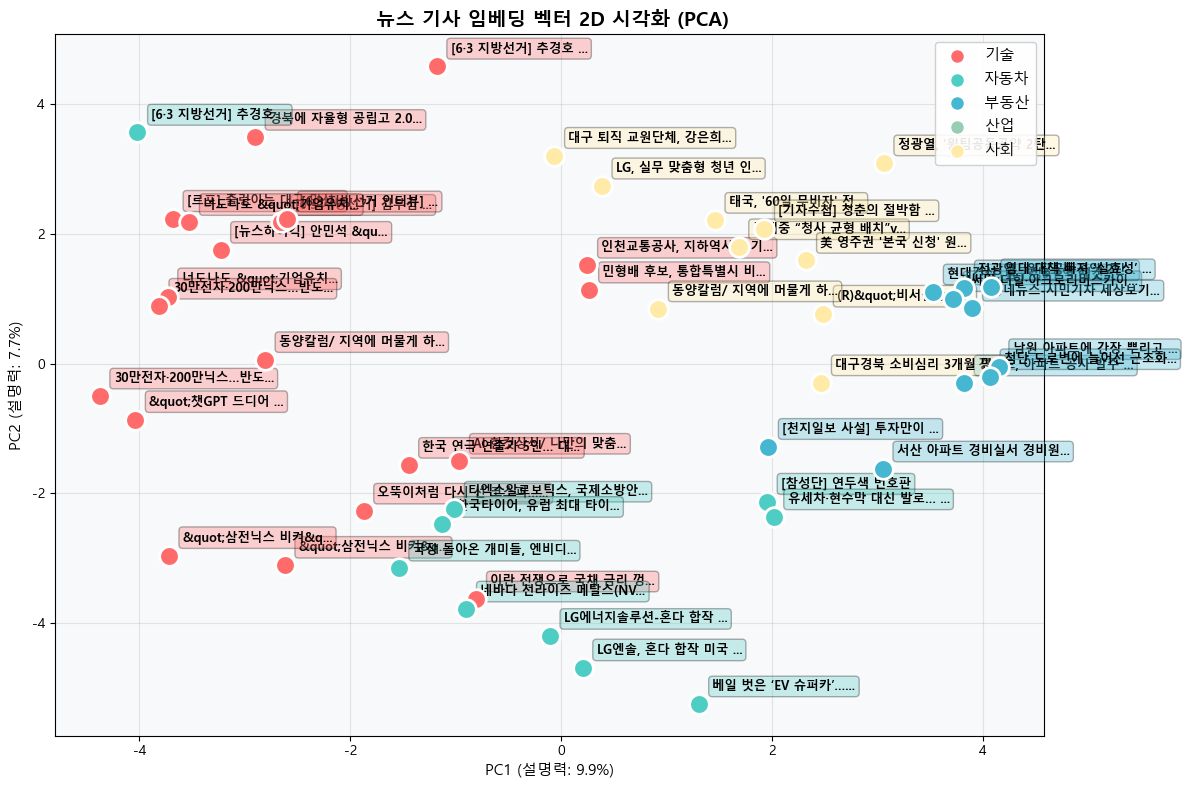


 의미적으로 유사한 기사들이 가까이 위치하는 것을 확인하세요!


In [26]:
# ============================================================
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 임베딩 벡터 2D 시각화 (PCA)
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# ============================================================
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.

import numpy as np
# 설명: numpy 모듈을 np라는 짧은 이름으로 불러온다.
import matplotlib.pyplot as plt
# 설명: matplotlib.pyplot 모듈을 plt라는 짧은 이름으로 불러온다.
from sklearn.decomposition import PCA
# 설명: sklearn.decomposition에서 PCA 기능을 가져온다.

# matplotlib 한글 폰트 설정 (Windows)
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
plt.rcParams['font.family'] = 'Malgun Gothic'
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
plt.rcParams['axes.unicode_minus'] = False
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

# 뉴스 기사의 임베딩 벡터 가져오기
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
all_data = collection_news.get(
# 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
    include=["embeddings", "metadatas"]
    # 설명: include 변수에 여러 값을 담은 리스트를 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

embeddings = np.array(all_data['embeddings'])
# 설명: embeddings 변수에 오른쪽 계산 결과나 설정값을 저장한다.
categories = [m['category'] for m in all_data['metadatas']]
# 설명: categories 변수에 여러 값을 담은 리스트를 저장한다.
titles = [m['title'] for m in all_data['metadatas']]
# 설명: titles 변수에 여러 값을 담은 리스트를 저장한다.

# PCA로 2D 축소
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
pca = PCA(n_components=2)
# 설명: pca 변수에 오른쪽 계산 결과나 설정값을 저장한다.
coords = pca.fit_transform(embeddings)
# 설명: coords 변수에 오른쪽 계산 결과나 설정값을 저장한다.

# 시각화
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
fig, ax = plt.subplots(figsize=(12, 8))
# 설명: 그래프를 그릴 그림과 축을 만든다.

# 카테고리별 색상
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
color_map = {
# 설명: 노드 타입별 색상 매핑표다
    "기술": "#FF6B6B",
    # 설명: 딕셔너리나 함수 인자에서 키와 값을 한 쌍으로 지정한다.
    "자동차": "#4ECDC4",
    # 설명: 딕셔너리나 함수 인자에서 키와 값을 한 쌍으로 지정한다.
    "부동산": "#45B7D1",
    # 설명: 딕셔너리나 함수 인자에서 키와 값을 한 쌍으로 지정한다.
    "산업": "#96CEB4",
    # 설명: 딕셔너리나 함수 인자에서 키와 값을 한 쌍으로 지정한다.
    "사회": "#FFEAA7",
    # 설명: 딕셔너리나 함수 인자에서 키와 값을 한 쌍으로 지정한다.
}
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

for i, (x, y) in enumerate(coords):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    color = color_map.get(categories[i], "#999999")
    # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
    ax.scatter(x, y, c=color, s=200, edgecolors='white', linewidths=2, zorder=5)
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    # 제목 줄이기
    # 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
    short_title = titles[i][:15] + "..." if len(titles[i]) > 15 else titles[i]
    # 설명: 길이나 개수를 계산해 short_title 변수에 저장한다.
    ax.annotate(short_title, (x, y), textcoords="offset points",
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
                xytext=(10, 10), fontsize=9, fontweight='bold',
                # 설명: xytext 변수에 여러 값을 묶은 결과를 저장한다.
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))
                # 설명: bbox 변수에 오른쪽 계산 결과나 설정값을 저장한다.

# 범례
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
for cat, color in color_map.items():
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    ax.scatter([], [], c=color, s=100, label=cat, edgecolors='white')
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

ax.set_title(' 뉴스 기사 임베딩 벡터 2D 시각화 (PCA)', fontsize=14, fontweight='bold')
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
ax.set_xlabel(f'PC1 (설명력: {pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
ax.set_ylabel(f'PC2 (설명력: {pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
ax.grid(True, alpha=0.3)
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
ax.set_facecolor('#f8f9fa')
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

plt.tight_layout()
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
plt.show()
# 설명: 완성된 그래프를 화면에 표시한다.

print("\n 의미적으로 유사한 기사들이 가까이 위치하는 것을 확인하세요!")# 설명: 확인용 결과를 화면에 출력한다.


### 그래프 DB
- Node, RelationShip(관계), 탐색(Traversal) 통해서 복잡한 관계를 효율적으로 쿼리하는 데이터베이스
- Node : 엔티티(사람, 장소, 물건 등)를 나타내는 기본단위
- RelationShip : 노드간의 연결, 방향과 타입 보유
- Property(속성) : Node, RelationShip에 붙는 key-value데이터
- Label : 노드의 타입 / 카테고리

### RDBMS vs Graph DB
- 테이블(행, 열)            노드 + 관계
- Join(외래키)              직접 연결
- 다중 Join(느림)           그래프 탐색(빠름)
- 쿼리(SQL)언어             Neo4j
- 정형데이터, 집계          관계중심 데이터

# [7교시]

In [ ]:
# ### Neo4j 로컬 환경 실행 가이드
# - 1. DB 서버 켜기 (가장 먼저 실행, 검은 창 끄지 말 것)
#     - 탐색기 경로: C:\neo4j-community-2026.04.0\bin
#     - cmd 실행 후 명령어: neo4j console
#     - 맨 마지막 줄 'Started.' 문구 확인

# - 2. Neo4j 화면(모니터) 띄우기
#     - Neo4j Desktop 프로그램 실행
#     - 좌측 [Remote connections] 클릭
#     - 우측 [Connect] -> [Query] 클릭

# - 3. .env 파일 세팅 (프로젝트 폴더 내)
#     - NEO4J_URI=bolt://127.0.0.1:7687
#     - NEO4J_USER=neo4j
#     - NEO4J_PASSWORD=본인비밀번호

# - 4. 파이썬 연결 세팅 코드
# import os
# from dotenv import load_dotenv
# from neo4j import GraphDatabase

# load_dotenv(override=True)
# NEO4J_URI = os.getenv('NEO4J_URI')
# NEO4J_USER = os.getenv('NEO4J_USER')
# NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
# NEO4J_DATABASE = "neo4j"

# driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
# driver.verify_connectivity()
# neo4j_available = True

In [29]:
import os
# 설명: os 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
from dotenv import load_dotenv
# 설명: dotenv에서 load_dotenv 기능을 가져온다.
load_dotenv(override=True)
# 설명: 함수나 클래스를 호출해 필요한 작업을 실행한다.

NEO4J_URI = os.getenv('NEO4J_URI')
# 설명: Neo4j 서버 접속 주소를 저장한다.
NEO4J_USER = os.getenv('NEO4J_USER')
# 설명: Neo4j 사용자 이름을 저장한다.
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')
# 설명: Neo4j 비밀번호를 저장한다.
NEO4J_DATABASE = "neo4j"
# 설명: 사용할 Neo4j 데이터베이스 이름을 지정한다.
from neo4j import GraphDatabase
# 설명: 노드와 관계를 함께 사용해 신뢰도나 연결 패턴을 분석하는 방식이다
driver = GraphDatabase.driver(NEO4J_URI,auth=(NEO4J_USER,NEO4J_PASSWORD))
# 설명: 노드와 관계를 함께 사용해 신뢰도나 연결 패턴을 분석하는 방식이다
driver.verify_connectivity()
# 설명: Neo4j 서버 연결이 되는지 확인한다.
neo4j_available = True# 설명: neo4j_available 변수에 오른쪽 계산 결과나 설정값을 저장한다.


In [31]:
# ### Cypher 기본 문법
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# - 노드생성
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
#     - CREATE(p:Person {name:'kim', age:28})
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# - 관계 생성
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
#     - MATCH(a:Person {name:'kim}),(b:Person {name:'lee'})  
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
#     - CREATE (a) -[:FRIEND{Since:2020}]->(b)   
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 패턴매칭
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# (a)-[:friend]->(b)   a가 b의 친구# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.


In [32]:
# 그래프 데이터 생성(Cypher 쿼리)
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.

def run_cypher(query, parameters=None):
    # 설명: run_cypher 함수를 정의한다. 반복해서 사용할 처리 과정을 이름으로 묶는 부분이다.
    """Neo4j에 Cypher 쿼리를 실행하고 결과를 반환합니다."""
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    with driver.session(database=NEO4J_DATABASE) as session:
        # 설명: 파일, 세션, 메모리 같은 자원을 안전하게 열고 닫기 위한 블록이다.
        result = session.run(query, parameters or {})
        # 설명: result 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        return [record.data() for record in result]
        # 설명: 함수 실행 결과를 호출한 곳으로 돌려준다.

if neo4j_available:
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    # 기존 데이터 삭제
    # 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
    run_cypher("MATCH (n) DETACH DELETE n")
    # 설명: Neo4j에 Cypher 쿼리를 실행한다.
    print("️ 기존 데이터 삭제 완료")
    # 설명: 확인용 결과를 화면에 출력한다.
    
    # 노드 생성
    # 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
    # 설명: create_query 변수에 오른쪽 계산 결과나 설정값을 저장한다. 아래 여러 줄 문자열은 원문 보존을 위해 내부 주석을 넣지 않았다.
    create_query = """
    CREATE (cs:Person {name: '김철수', age: 28, job: '개발자', city: '서울'})
    CREATE (yh:Person {name: '이영희', age: 32, job: '디자이너', city: '서울'})
    CREATE (ms:Person {name: '박민수', age: 25, job: '개발자', city: '부산'})
    CREATE (je:Person {name: '최지은', age: 30, job: 'PM', city: '서울'})
    CREATE (hj:Person {name: '정호진', age: 27, job: '데이터분석가', city: '대전'})
    CREATE (sj:Person {name: '한수진', age: 29, job: '개발자', city: '서울'})
    
    CREATE (cs)-[:FRIEND {since: 2020}]->(yh)
    CREATE (cs)-[:FRIEND {since: 2021}]->(ms)
    CREATE (yh)-[:COLLEAGUE {company: '테크Corp'}]->(je)
    CREATE (je)-[:MANAGES {since: 2022}]->(cs)
    CREATE (ms)-[:FRIEND {since: 2023}]->(hj)
    CREATE (hj)-[:COLLEAGUE {company: '데이터Lab'}]->(sj)
    CREATE (sj)-[:FRIEND {since: 2019}]->(cs)
    CREATE (yh)-[:FOLLOWS]->(hj)
    CREATE (je)-[:FOLLOWS]->(sj)
    
    RETURN count(*) as created
    """
    
    run_cypher(create_query)
    # 설명: Neo4j에 Cypher 쿼리를 실행한다.
    print(" Neo4j에 그래프 데이터 생성 완료!")
    # 설명: 확인용 결과를 화면에 출력한다.
    
    # 확인
    # 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
    result = run_cypher("MATCH (n:Person) RETURN n.name AS name, n.job AS job, n.city AS city")
    # 설명: Neo4j에 Cypher 쿼리를 실행한다.
    print(f"\n 생성된 노드:")
    # 설명: 확인용 결과를 화면에 출력한다.
    for r in result:
        # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
        print(f"    {r['name']} — {r['job']}, {r['city']}")
        # 설명: 확인용 결과를 화면에 출력한다.
else:
    # 설명: 앞 조건에 해당하지 않는 나머지 경우에 실행된다.
    print("️ Neo4j 서버에 연결되어 있지 않아 이 셀을 건너뜁니다.")
    # 설명: 확인용 결과를 화면에 출력한다.
    print("   위의 Cypher 쿼리 코드를 읽으며 문법을 학습하세요.")    # 설명: 확인용 결과를 화면에 출력한다.


️ 기존 데이터 삭제 완료
 Neo4j에 그래프 데이터 생성 완료!

 생성된 노드:
    김철수 — 개발자, 서울
    이영희 — 디자이너, 서울
    박민수 — 개발자, 부산
    최지은 — PM, 서울
    정호진 — 데이터분석가, 대전
    한수진 — 개발자, 서울


In [33]:
if neo4j_available:
    # 설명: 조건이 참일 때만 아래 들여쓰기된 코드를 실행한다.
    print(" 1. 모든 FRIEND 관계 조회")
    # 설명: 확인용 결과를 화면에 출력한다.
    print("="*50)
    # 설명: 확인용 결과를 화면에 출력한다.
    # 설명: Neo4j에 Cypher 쿼리를 실행한다. 아래 여러 줄 문자열은 원문 보존을 위해 내부 주석을 넣지 않았다.
    results = run_cypher("""
        MATCH (a:Person)-[r:FRIEND]->(b:Person)
        RETURN a.name AS from_person, b.name AS to_person, r.since AS since
        ORDER BY r.since
    """)
    for r in results:
        # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
        print(f"  {r['from_person']} ──FRIEND──> {r['to_person']} (since {r['since']})")
        # 설명: 확인용 결과를 화면에 출력한다.
    
    print(f"\n\n 2. 서울에 사는 개발자의 친구")
    # 설명: 확인용 결과를 화면에 출력한다.
    print("="*50)
    # 설명: 확인용 결과를 화면에 출력한다.
    # 설명: Neo4j에 Cypher 쿼리를 실행한다. 아래 여러 줄 문자열은 원문 보존을 위해 내부 주석을 넣지 않았다.
    results = run_cypher("""
        MATCH (a:Person {city: '서울', job: '개발자'})-[:FRIEND]->(b:Person)
        RETURN a.name AS person, b.name AS friend, b.city AS friend_city
    """)
    for r in results:
        # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
        print(f"  {r['person']}  {r['friend']} ({r['friend_city']})")
        # 설명: 확인용 결과를 화면에 출력한다.
    
    print(f"\n\n 3. 2-hop 관계 탐색 (친구의 친구)")
    # 설명: 확인용 결과를 화면에 출력한다.
    print("="*50)
    # 설명: 확인용 결과를 화면에 출력한다.
    # 설명: Neo4j에 Cypher 쿼리를 실행한다. 아래 여러 줄 문자열은 원문 보존을 위해 내부 주석을 넣지 않았다.
    results = run_cypher("""
        MATCH (a:Person {name: '김철수'})-[:FRIEND]->()-[:FRIEND]->(fof:Person)
        WHERE fof.name <> '김철수'
        RETURN DISTINCT fof.name AS friend_of_friend, fof.job AS job
    """)
    for r in results:
        # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
        print(f"  김철수의 친구의 친구: {r['friend_of_friend']} ({r['job']})")
        # 설명: 확인용 결과를 화면에 출력한다.
    
    print(f"\n\n 4. 최단 경로 탐색")
    # 설명: 확인용 결과를 화면에 출력한다.
    print("="*50)
    # 설명: 확인용 결과를 화면에 출력한다.
    # 설명: Neo4j에 Cypher 쿼리를 실행한다. 아래 여러 줄 문자열은 원문 보존을 위해 내부 주석을 넣지 않았다.
    results = run_cypher("""
        MATCH path = shortestPath(
            (a:Person {name: '김철수'})-[*]-(b:Person {name: '정호진'})
        )
        RETURN [node IN nodes(path) | node.name] AS path_nodes,
               length(path) AS hops
    """)
    for r in results:
        # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
        print(f"  경로: {'  '.join(r['path_nodes'])} ({r['hops']} hops)")
        # 설명: 확인용 결과를 화면에 출력한다.

else:
    # 설명: 앞 조건에 해당하지 않는 나머지 경우에 실행된다.
    print("️ Neo4j 미연결 — Cypher 쿼리 코드를 읽으며 학습하세요.")
    # 설명: 확인용 결과를 화면에 출력한다.
    print()
    # 설명: 확인용 결과를 화면에 출력한다.
    print(" 위 코드에서 사용된 Cypher 패턴 정리:")
    # 설명: 확인용 결과를 화면에 출력한다.
    print("   MATCH (a)-[r:TYPE]->(b)     : 패턴 매칭")
    # 설명: 확인용 결과를 화면에 출력한다.
    print("   WHERE a.prop = 'value'       : 조건 필터링")
    # 설명: 확인용 결과를 화면에 출력한다.
    print("   RETURN a.name, b.name        : 결과 반환")
    # 설명: 확인용 결과를 화면에 출력한다.
    print("   (a)-[:FRIEND]->()-[:FRIEND]->(c) : 2-hop 탐색")
    # 설명: 확인용 결과를 화면에 출력한다.
    print("   shortestPath((a)-[*]-(b))    : 최단 경로")    # 설명: 확인용 결과를 화면에 출력한다.


 1. 모든 FRIEND 관계 조회
  한수진 ──FRIEND──> 김철수 (since 2019)
  김철수 ──FRIEND──> 이영희 (since 2020)
  김철수 ──FRIEND──> 박민수 (since 2021)
  박민수 ──FRIEND──> 정호진 (since 2023)


 2. 서울에 사는 개발자의 친구
  김철수  이영희 (서울)
  김철수  박민수 (부산)
  한수진  김철수 (서울)


 3. 2-hop 관계 탐색 (친구의 친구)
  김철수의 친구의 친구: 정호진 (데이터분석가)


 4. 최단 경로 탐색
  경로: 김철수  이영희  정호진 (2 hops)


### PART1 VectorDB : 상품의미검색
- 상품설명을 임베딩해서 맥락 기반의 검색 수행
### PART2 GraphDB : 구매/리뷰 
- 유저-상품-리뷰간의 그래프생성 및 분석
### PART3 GraphRAG & 추천
- 의미검색결과에서 신뢰도(그래프 중심성)높은 상품 필터링

In [34]:
import chromadb
# 설명: chromadb 모듈을 불러와 아래 코드에서 사용할 수 있게 한다.
from chromadb.utils import embedding_functions
# 설명: chromadb.utils에서 embedding_functions 기능을 가져온다.
import networkx as nx
# 설명: networkx 모듈을 nx라는 짧은 이름으로 불러온다.
import matplotlib.pyplot as plt
# 설명: matplotlib.pyplot 모듈을 plt라는 짧은 이름으로 불러온다.
import numpy as np
# 설명: numpy 모듈을 np라는 짧은 이름으로 불러온다.

plt.rcParams['font.family'] = 'Malgun Gothic'
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
plt.rcParams['axes.unicode_minus'] = False
# 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

products = [
# 설명: 실습용 상품 데이터 목록이다
    {"id": "p1", "name": "프로그래밍용 고성능 노트북", "desc": "최신 14세대 CPU와 32GB RAM을 탑재하여 무거운 딥러닝 및 개발 작업에 최적화된 랩탑입니다.", "category": "가전"},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"id": "p2", "name": "초경량 사무용 랩탑", "desc": "1kg 미만의 가벼운 무게로 카페나 도서관에서 문서 작업 및 웹서핑을 하기에 매우 좋은 노트북.", "category": "가전"},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"id": "p3", "name": "전문가용 미러리스 카메라", "desc": "4K 60fps 동영상 촬영과 빠르고 정확한 AF를 지원하여 유튜버 및 프로 사진작가에게 적합한 카메라.", "category": "가전"},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"id": "p4", "name": "편안한 러닝화", "desc": "쿠셔닝이 뛰어나고 통풍이 잘 되어 장시간 달리기나 헬스장 운동 시 발의 피로를 최소화해주는 운동화.", "category": "패션"},
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
    {"id": "p5", "name": "방수 트레킹화", "desc": "고어텍스 소재로 비오는 날이나 거친 산악 지형에서도 발을 쾌적하게 보호하는 등산용 신발.", "category": "패션"}
    # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
]# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.


# [8교시]

In [35]:
# 1. Chroma 인메모리 클라이언트 및 다국어 임베딩 설정
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
client = chromadb.Client()
# 설명: ChromaDB 클라이언트를 만든다.
st_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
# 설명: 문장 임베딩 함수를 만든다.
    model_name='paraphrase-multilingual-MiniLM-L12-v2'
    # 설명: model_name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
# 기존 컬렉션 초기화 후 재생성
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
try:
    # 설명: 오류가 날 수 있는 코드를 안전하게 시도하는 블록을 시작한다.
    client.delete_collection('ecommerce')
    # 설명: 기존 Chroma 컬렉션을 삭제한다.
except Exception:
    # 설명: try 블록에서 오류가 발생했을 때 실행되는 예외 처리 부분이다.
    pass    
    # 설명: 아무 작업도 하지 않고 자리만 채우는 코드다.
product_collection =  client.create_collection(
# 설명: 새 Chroma 컬렉션을 생성한다.
    name ='ecommerce',
    # 설명: name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    embedding_function=st_ef,
    # 설명: embedding_function 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    metadata={'hnsw:space':'cosine'}
    # 설명: metadata 변수에 키와 값을 묶은 딕셔너리/집합 데이터를 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
# 2. 가상의 이커머스 상품 데이터 (노트북, 카메라, 신발 등)
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 3. Vector DB에 데이터 삽입
# 설명: 문장 의미를 숫자 벡터로 바꿔 유사도를 비교하는 방식이다
product_collection.add(
# 설명: 벡터DB 컬렉션에 문서와 메타데이터를 저장한다.
    ids = [f'product_{i:03d}' for i, p in enumerate(products)],
    # 설명: ids 변수에 여러 값을 담은 리스트를 저장한다.
    documents=[p['desc'] for p in products],
    # 설명: documents 변수에 여러 값을 담은 리스트를 저장한다.
    metadatas=[
    # 설명: metadatas 변수에 여러 값을 담은 리스트를 저장한다.
        { 'name':p['name'],'category':p['category']}
        # 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
            for p in products        
            # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    ]
    # 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
# 4. 의미 기반 검색 테스트
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
query = '산에 갈 때 신기 좋은 튼튼한 신발'
# 설명: 검색하거나 모델에게 전달할 사용자 질문 문장이다
results = product_collection.query(
# 설명: 벡터DB에서 의미적으로 가까운 문서를 검색한다.
    query_texts=[query],
    # 설명: query_texts 변수에 여러 값을 담은 리스트를 저장한다.
    n_results=5  # top_5
    # 설명: n_results 변수에 오른쪽 계산 결과나 설정값을 저장한다.
)
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
for doc, meta,dist in zip(results['documents'][0],results['metadatas'][0],results['distances'][0]):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    similarity = 1- dist # 코사인거리->유사도 변환    
    # 설명: similarity 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    print(similarity,doc,meta,dist)    # 설명: 확인용 결과를 화면에 출력한다.


c:\miniconda\envs\edu_env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


0.7859519720077515 고어텍스 소재로 비오는 날이나 거친 산악 지형에서도 발을 쾌적하게 보호하는 등산용 신발. {'category': '패션', 'name': '방수 트레킹화'} 0.21404802799224854
0.4105861186981201 쿠셔닝이 뛰어나고 통풍이 잘 되어 장시간 달리기나 헬스장 운동 시 발의 피로를 최소화해주는 운동화. {'name': '편안한 러닝화', 'category': '패션'} 0.5894138813018799
0.1638472080230713 1kg 미만의 가벼운 무게로 카페나 도서관에서 문서 작업 및 웹서핑을 하기에 매우 좋은 노트북. {'category': '가전', 'name': '초경량 사무용 랩탑'} 0.8361527919769287
0.07583683729171753 4K 60fps 동영상 촬영과 빠르고 정확한 AF를 지원하여 유튜버 및 프로 사진작가에게 적합한 카메라. {'name': '전문가용 미러리스 카메라', 'category': '가전'} 0.9241631627082825
-0.0030096769332885742 최신 14세대 CPU와 32GB RAM을 탑재하여 무거운 딥러닝 및 개발 작업에 최적화된 랩탑입니다. {'name': '프로그래밍용 고성능 노트북', 'category': '가전'} 1.0030096769332886


### 그래프 DB를 이용한 신뢰도 분석
- 제품검색은 VectorDB가 잘함
- 이 제품을 파는 판매자나 리뷰가 믿을만한가? -> 관계데이터인 그래프DB가 유리함
- 유저 - 상품간의 구매 및 리뷰 그래프 모델링

In [36]:
# 그래프 생성
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
G = nx.DiGraph()
# 설명: 노드와 관계를 함께 사용해 신뢰도나 연결 패턴을 분석하는 방식이다
# 상품 노드추가(VectorDB id 사용)
# 설명: 문장 의미를 숫자 벡터로 바꿔 유사도를 비교하는 방식이다
for p in products:
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    G.add_node( p['id'], type='Product' , name = p['name']  )
    # 설명: 그래프에 노드를 추가한다.

# 유저노드 추가
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
users = ['User_A','User_B','User_C',"Spammer_1","Spammer_2"]
# 설명: 그래프에 추가할 사용자 노드 이름 목록이다
for u in users:
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    G.add_node(u, type='User', name=u)
    # 설명: 그래프에 노드를 추가한다.
# 구매 및 추천 관계 추가
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
# 정상유저들의 패턴 : 여러 상품을 구매하고 교류
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
edges = [
# 설명: 정상 사용자의 구매/팔로우 관계 목록이다
    ("User_A", "p5", "PURCHASED"), ("User_A", "p4", "PURCHASED"),
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    ("User_B", "p5", "PURCHASED"), ("User_B", "p1", "PURCHASED"),
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    ("User_C", "p1", "PURCHASED"), ("User_C", "p3", "PURCHASED"),
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    ("User_A", "User_B", "FOLLOWS"), ("User_B", "User_C", "FOLLOWS")
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
]
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.
# 사기패턴 : 특정 스패머들이 특정 상품(p2)만 집중적으로 가짜 구매/리뷰
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
spam_edges = [
# 설명: 스팸 사용자들이 만든 의심 관계 목록이다
    ("Spammer_1", "p2", "PURCHASED"), ("Spammer_2", "p2", "PURCHASED"),
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    ("Spammer_1", "p2", "REVIEWED_5_STAR"), ("Spammer_2", "p2", "REVIEWED_5_STAR"),
    # 설명: 여러 인자나 리스트 항목 중 하나를 이어서 전달한다.
    ("Spammer_1", "Spammer_2", "FOLLOWS") # 자기들끼리만 연결됨
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
]
# 설명: 위에서 시작한 리스트/딕셔너리/함수 호출 블록을 닫는다.

for src,dst,rel in edges + spam_edges:
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    G.add_edge(src,dst,type=rel)
    # 설명: 그래프에 방향 관계를 추가한다.

print(f'그래프생성 완료 : 노드 : {G.number_of_nodes()}  엣지 : {G.number_of_edges()}')# 설명: 확인용 결과를 화면에 출력한다.


그래프생성 완료 : 노드 : 10  엣지 : 11


In [37]:
# 페이지랭크(PageRnak)알고리즘 : 상품의 진짜 신뢰도 분석
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
raw_pr_scores = nx.pagerank(G, alpha=0.85)
# 설명: 그래프의 중요도 점수인 PageRank를 계산한다.

suspicious_users = {n for n, data in G.nodes(data=True) if data['type'] == 'User' and str(n).startswith('Spammer')}
# 설명: 딕셔너리 형태로 관련 값을 묶어 전달한다.
trusted_nodes = [n for n in G.nodes() if n not in suspicious_users]
# 설명: 스패머를 제외하고 신뢰도 계산에 사용할 노드 목록이다
trusted_G = G.subgraph(trusted_nodes).copy()
# 설명: 필요한 노드만 골라 부분 그래프를 만든다.
pr_scores = nx.pagerank(trusted_G, alpha=0.85)
# 설명: 그래프의 중요도 점수인 PageRank를 계산한다.

print("원본 그래프 PageRank (스팸 영향 포함)")
# 설명: 연결 구조를 기반으로 노드의 상대적 중요도를 계산하는 알고리즘이다
print("-" * 50)
# 설명: 확인용 결과를 화면에 출력한다.
for node, score in sorted(raw_pr_scores.items(), key=lambda x: -x[1]):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    node_data = G.nodes[node]
    # 설명: node_data 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    node_type = node_data['type']
    # 설명: node_type 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    name = node_data['name']
    # 설명: name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    bar = '*' * int(score * 80)
    # 설명: bar 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    print(f"[{node_type}] {name[:12]:<12} | 점수: {score:.3f} {bar}")
    # 설명: 확인용 결과를 화면에 출력한다.

print("\n신뢰도 보정 PageRank (Spammer 제외)")
# 설명: 연결 구조를 기반으로 노드의 상대적 중요도를 계산하는 알고리즘이다
print("-" * 50)
# 설명: 확인용 결과를 화면에 출력한다.
for node, score in sorted(pr_scores.items(), key=lambda x: -x[1]):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    node_data = trusted_G.nodes[node]
    # 설명: node_data 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    node_type = node_data['type']
    # 설명: node_type 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    name = node_data['name']
    # 설명: name 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    bar = '*' * int(score * 80)
    # 설명: bar 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    print(f"[{node_type}] {name[:12]:<12} | 점수: {score:.3f} {bar}")    # 설명: 확인용 결과를 화면에 출력한다.


원본 그래프 PageRank (스팸 영향 포함)
--------------------------------------------------
[Product] 초경량 사무용 랩탑   | 점수: 0.174 *************
[Product] 프로그래밍용 고성능 노 | 점수: 0.128 **********
[Product] 방수 트레킹화      | 점수: 0.109 ********
[Product] 전문가용 미러리스 카메 | 점수: 0.104 ********
[User] Spammer_2    | 점수: 0.094 *******
[User] User_C       | 점수: 0.090 *******
[Product] 편안한 러닝화      | 점수: 0.085 ******
[User] User_B       | 점수: 0.085 ******
[User] User_A       | 점수: 0.066 *****
[User] Spammer_1    | 점수: 0.066 *****

신뢰도 보정 PageRank (Spammer 제외)
--------------------------------------------------
[Product] 프로그래밍용 고성능 노 | 점수: 0.175 **************
[Product] 방수 트레킹화      | 점수: 0.148 ***********
[Product] 전문가용 미러리스 카메 | 점수: 0.142 ***********
[User] User_C       | 점수: 0.123 *********
[Product] 편안한 러닝화      | 점수: 0.116 *********
[User] User_B       | 점수: 0.116 *********
[Product] 초경량 사무용 랩탑   | 점수: 0.090 *******
[User] User_A       | 점수: 0.090 *******


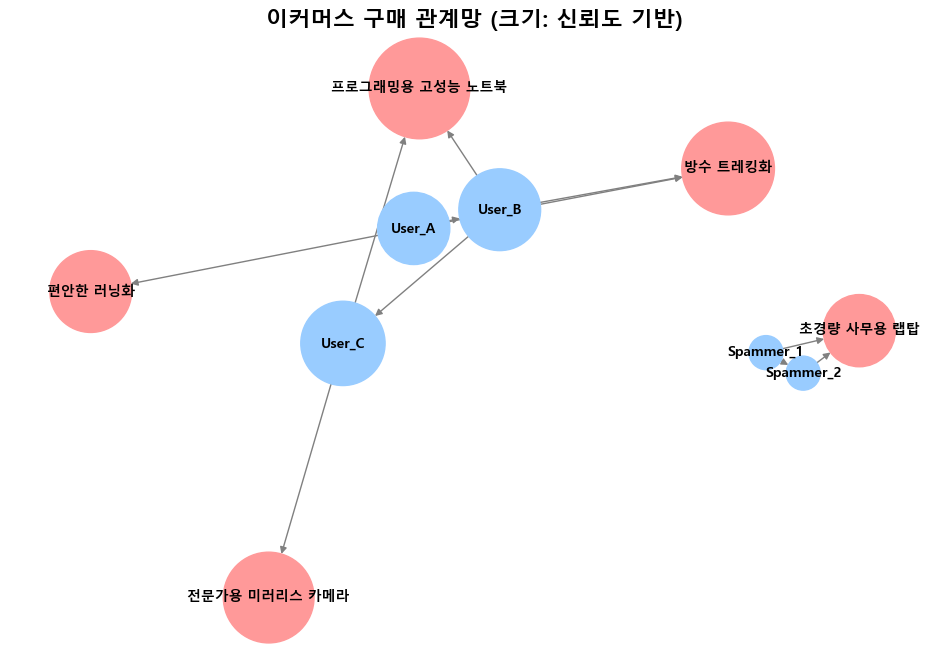

In [38]:
# 3. 그래프 시각화
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
fig, ax = plt.subplots(figsize=(12, 8))
# 설명: 그래프를 그릴 그림과 축을 만든다.
pos = nx.spring_layout(G, seed=42)
# 설명: 그래프 노드가 보기 좋게 배치될 좌표를 계산한다.

# 한글 라벨이 깨지지 않도록 폰트를 명시적으로 지정
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
label_font = 'Malgun Gothic'
# 설명: 그래프 라벨에 사용할 한글 폰트 이름이다

# 노드 타입별 색상 지정
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
color_map = {'Product': '#FF9999', 'User': '#99CCFF'}
# 설명: 노드 타입별 색상 매핑표다
colors = [color_map[G.nodes[n]['type']] for n in G.nodes()]
# 설명: 각 노드에 적용할 색상 목록이다
sizes = [pr_scores.get(n, 0.02) * 30000 for n in G.nodes()] # 스팸 노드는 작은 기본 크기 사용
# 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.

nx.draw(G, pos, with_labels=True, labels={n: G.nodes[n]['name'] for n in G.nodes()},
# 설명: NetworkX 그래프를 matplotlib 화면에 그린다.
        node_color=colors, node_size=sizes, font_size=10, font_weight='bold', 
        # 설명: node_color 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        font_family=label_font,
        # 설명: font_family 변수에 오른쪽 계산 결과나 설정값을 저장한다.
        edge_color='gray', arrows=True, ax=ax)
        # 설명: edge_color 변수에 오른쪽 계산 결과나 설정값을 저장한다.
plt.title("이커머스 구매 관계망 (크기: 신뢰도 기반)", fontsize=16, fontweight='bold')
# 설명: 그래프 제목을 설정한다.
plt.show()
# 설명: 완성된 그래프를 화면에 표시한다.


### part3 Vector DB + Graph DB

In [39]:
# 1. 사용자 질의
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
query = "카페에서 쓰기 좋은 코딩용 노트북"
# 설명: 검색하거나 모델에게 전달할 사용자 질문 문장이다

# 2. Vector DB에서 1차 의미 검색 (Top 3)
# 설명: 문장 의미를 숫자 벡터로 바꿔 유사도를 비교하는 방식이다
results = product_collection.query(query_texts=[query], n_results=3)
# 설명: 벡터DB에서 의미적으로 가까운 문서를 검색한다.

print(" [1차 필터링] Vector DB 검색 결과 (의미 기반)")
# 설명: 문장 의미를 숫자 벡터로 바꿔 유사도를 비교하는 방식이다
print("-" * 50)
# 설명: 확인용 결과를 화면에 출력한다.
candidates = []
# 설명: Vector 검색 결과를 Graph 점수와 합칠 후보 목록이다
for doc, meta, dist, p_id in zip(results['documents'][0], results['metadatas'][0], results['distances'][0], results['ids'][0]):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    sim = 1 - dist
    # 설명: sim 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    candidates.append({"id": p_id, "name": meta['name'], "vector_score": sim})
    # 설명: 리스트에 새 항목을 뒤쪽으로 추가한다.
    print(f"상품명: {meta['name']:<15} | Vector 유사도: {sim:.4f}")
    # 설명: 문장 의미를 숫자 벡터로 바꿔 유사도를 비교하는 방식이다

# 3. Graph DB 신뢰도 융합 (Hybrid Scoring)
# 설명: 노드와 관계를 함께 사용해 신뢰도나 연결 패턴을 분석하는 방식이다
print("\n [최종 추천] Vector 유사도 + Graph 신뢰도 융합 결과")
# 설명: 문장 의미를 숫자 벡터로 바꿔 유사도를 비교하는 방식이다
print("-" * 50)
# 설명: 확인용 결과를 화면에 출력한다.

alpha = 0.6 # 벡터 유사도 비중
# 설명: 최종 점수에서 벡터 유사도가 차지하는 비중이다
beta = 0.4  # 그래프 신뢰도 비중
# 설명: 최종 점수에서 그래프 신뢰도가 차지하는 비중이다

for c in candidates:
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    v_score = c['vector_score']
    # 설명: v_score 변수에 오른쪽 계산 결과나 설정값을 저장한다.
    # PageRank 점수 정규화 (가독성을 위해 10배 곱함)
    # 설명: 연결 구조를 기반으로 노드의 상대적 중요도를 계산하는 알고리즘이다
    g_score = pr_scores.get(c['id'], 0) * 10 
    # 설명: 딕셔너리에서 키에 해당하는 값을 안전하게 꺼낸다.
    
    # 하이브리드 점수 산출
    # 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
    final_score = (v_score * alpha) + (g_score * beta)
    # 설명: final_score 변수에 여러 값을 묶은 결과를 저장한다.
    c['final_score'] = final_score
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.
    c['graph_score'] = g_score
    # 설명: 위 코드 흐름에 필요한 값을 만들거나 다음 작업으로 전달하는 코드다.

# 최종 점수순 정렬
# 설명: 학습 흐름을 설명하기 위해 작성된 기존 주석이다.
candidates.sort(key=lambda x: x['final_score'], reverse=True)
# 설명: 점수나 조건 기준으로 데이터를 정렬한다.

for i, c in enumerate(candidates):
    # 설명: 여러 항목을 하나씩 꺼내면서 아래 코드를 반복 실행한다.
    print(f"{i+1}위: {c['name']:<15}")
    # 설명: 확인용 결과를 화면에 출력한다.
    print(f"    └ 합산 점수: {c['final_score']:.4f} (Vector: {c['vector_score']:.4f}, Graph: {c['graph_score']:.4f})")
    # 설명: 문장 의미를 숫자 벡터로 바꿔 유사도를 비교하는 방식이다


 [1차 필터링] Vector DB 검색 결과 (의미 기반)
--------------------------------------------------
상품명: 초경량 사무용 랩탑      | Vector 유사도: 0.6709
상품명: 프로그래밍용 고성능 노트북  | Vector 유사도: 0.3848
상품명: 전문가용 미러리스 카메라   | Vector 유사도: 0.2273

 [최종 추천] Vector 유사도 + Graph 신뢰도 융합 결과
--------------------------------------------------
1위: 초경량 사무용 랩탑     
    └ 합산 점수: 0.4025 (Vector: 0.6709, Graph: 0.0000)
2위: 프로그래밍용 고성능 노트북 
    └ 합산 점수: 0.2309 (Vector: 0.3848, Graph: 0.0000)
3위: 전문가용 미러리스 카메라  
    └ 합산 점수: 0.1364 (Vector: 0.2273, Graph: 0.0000)
